# RAG Pipeline Evaluation Analysis

Analyses the binary-judge evaluation results produced by `src/process/rag_pipeline.py`.

**What this notebook covers:**
1. Load & validate evaluation CSVs
2. Overall accuracy per strategy
3. Per-decile accuracy — popularity bias
4. Retrieval quality — Recall@K
4b. Retrieval failure → output failure correlation
4c. Popularity skew in retrieval errors
5. Per-dataset breakdown
5b. Per-dataset × per-decile accuracy
6. Score distribution & reasoning inspection
7. Cross-strategy comparison
8. Export summary

In [1]:
from __future__ import annotations

import ast
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Repo root on path ─────────────────────────────────────────────────────────
# In a notebook __file__ is undefined; walk up from cwd (notebook is 2 levels deep)
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / "config.py").exists() and _REPO_ROOT.parent != _REPO_ROOT:
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from config import DATA_DIR

print(f"DATA_DIR: {DATA_DIR}")

DATA_DIR: /Users/cyro/Documents/VSC/PopularityBias/data


## Configuration

Set `COLLECTION_NAME` and `OUTPUT_DIR` to match the `PipelineConfig` used when the pipeline was run.

In [ ]:
# ── Match these to your PipelineConfig values ─────────────────────────────────
COLLECTION_NAME = "wiki_full_bil"
OUTPUT_DIR      = "evaluation_results_text_2B_200_exact_match"
STRATEGIES      = ["zero_shot", "approximation", "bm25"]
NUM_DECILES     = 10

# "unweighted"    — decile boundaries based on raw article popularity
# "chunk_weighted" — decile boundaries weighted by number of indexed chunks
DECILE_MODE     = "chunk_weighted"

RESULTS_DIR = Path(DATA_DIR) / COLLECTION_NAME / OUTPUT_DIR
print(f"Looking for results in: {RESULTS_DIR}")

# Confirm files exist
for s in STRATEGIES:
    p = RESULTS_DIR / f"evaluation_results_{s}.csv"
    status = "found" if p.exists() else "MISSING"
    print(f"  {p.name}: {status}")

Looking for results in: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match
  evaluation_results_zero_shot.csv: found
  evaluation_results_approximation.csv: found
  evaluation_results_bm25.csv: found


## 1. Load & Validate Results

In [3]:
def _parse_metadata(val) -> dict:
    """Parse the 'metadata' column, which may be a dict, a JSON string, or a Python repr."""
    if isinstance(val, dict):
        return val
    if isinstance(val, str):
        try:
            import json as _json
            return _json.loads(val)
        except Exception:
            pass
        try:
            import re
            # Clean numpy types
            cleaned = re.sub(r'np\.float64\(([^)]+)\)', r'\1', val)
            cleaned = re.sub(r'np\.int64\(([^)]+)\)', r'\1', cleaned)
            return ast.literal_eval(cleaned)
        except Exception:
            pass
    return {}


def _parse_id_list(val) -> list[int]:
    """Coerce a retrieved_doc_ids value to a list of ints.

    The field may arrive as:
      - already a list (e.g. [19367245])
      - a string repr  (e.g. "[19367245]")
    """
    if isinstance(val, list):
        # Filter out empty strings, None, and NaN, then convert to int
        return [int(float(v)) for v in val if v and str(v).strip() and str(v).lower() not in ('nan', 'none', '')]
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return [int(float(v)) for v in parsed if v and str(v).strip() and str(v).lower() not in ('nan', 'none', '')]
        except Exception:
            pass
    return []


def _parse_float_list(val) -> list[float]:
    """Coerce a retrieved_doc_popularity value to a list of floats.

    The field may arrive as:
      - already a list (e.g. [6.571])
      - a string repr  (e.g. "[6.571]")
    """
    if isinstance(val, list):
        # Filter out empty strings, None, and NaN
        return [float(v) for v in val if v and str(v).strip() and str(v).lower() not in ('nan', 'none', '')]
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return [float(v) for v in parsed if v and str(v).strip() and str(v).lower() not in ('nan', 'none', '')]
        except Exception:
            pass
    return []


def load_results(strategy: str) -> pd.DataFrame:
    """Load and normalise an evaluation CSV for one strategy."""
    path = RESULTS_DIR / f"evaluation_results_{strategy}.csv"
    df = pd.read_csv(path)

    # Unpack metadata dict into flat columns
    meta = df["metadata"].apply(_parse_metadata)
    df["wikipedia_id"]      = meta.apply(lambda m: m.get("wikipedia_id"))
    df["decile_unweighted"]   = meta.apply(lambda m: int(m.get("decile_unweighted", m.get("decile", -1))))
    df["decile_chunk_weighted"] = meta.apply(lambda m: int(m.get("decile_chunk_weighted", m.get("decile", -1))))
    _decile_col = "decile_chunk_weighted" if DECILE_MODE == "chunk_weighted" else "decile_unweighted"
    df["decile"] = df[_decile_col]
    df["dataset"]           = meta.apply(lambda m: m.get("dataset", "unknown"))
    df["retrieved_doc_ids"] = meta.apply(lambda m: _parse_id_list(m.get("retrieved_doc_ids", [])))
    df["retrieved_doc_popularity"] = meta.apply(lambda m: _parse_float_list(m.get("retrieved_doc_popularity", [])))
    df["popularity_avg"] = pd.to_numeric(
        meta.apply(lambda m: m.get("popularity_avg")), errors="coerce"
    )

    # Normalise wikipedia_id to int for consistent comparison
    df["wikipedia_id_int"] = pd.to_numeric(df["wikipedia_id"], errors="coerce")

    # Hit: is the target doc anywhere in the retrieved list?
    df["hit"] = df.apply(
        lambda r: int(r["wikipedia_id_int"]) in r["retrieved_doc_ids"]
        if pd.notna(r["wikipedia_id_int"]) and r["retrieved_doc_ids"]
        else False,
        axis=1,
    )

    # Normalise evaluation_score to bool
    df["correct"] = df["evaluation_score"].map(
        lambda v: bool(v) if not isinstance(v, str)
        else v.strip().lower() in {"true", "1", "yes"}
    )

    df["strategy"] = strategy
    return df


raw: dict[str, pd.DataFrame] = {}
for s in STRATEGIES:
    try:
        raw[s] = load_results(s)
        print(f"  {s}: {len(raw[s]):,} rows")
        has_ids = raw[s]["retrieved_doc_ids"].apply(bool).sum()
        print(f"    retrieved_doc_ids present in {has_ids:,} / {len(raw[s]):,} rows")
        has_pop = raw[s]["retrieved_doc_popularity"].apply(bool).sum()
        print(f"    retrieved_doc_popularity present in {has_pop:,} / {len(raw[s]):,} rows")
        has_target_pop = raw[s]["popularity_avg"].notna().sum()
        print(f"    popularity_avg (target) present in {has_target_pop:,} / {len(raw[s]):,} rows")
    except FileNotFoundError:
        print(f"  {s}: file not found — skipping")

LOADED = list(raw.keys())
assert LOADED, "No result files found — run src/process/rag_pipeline.py first."

# Combined view
combined = pd.concat(raw.values(), ignore_index=True)
print(f"\nTotal rows across all strategies: {len(combined):,}")
combined[["question", "wikipedia_id", "decile", "dataset", "retrieved_doc_ids", "retrieved_doc_popularity", "popularity_avg", "hit", "correct", "strategy"]].head(3)

  zero_shot: 1,930 rows
    retrieved_doc_ids present in 0 / 1,930 rows
    retrieved_doc_popularity present in 0 / 1,930 rows
    popularity_avg (target) present in 1,930 / 1,930 rows
  approximation: 1,930 rows
    retrieved_doc_ids present in 1,930 / 1,930 rows
    retrieved_doc_popularity present in 0 / 1,930 rows
    popularity_avg (target) present in 1,930 / 1,930 rows
  bm25: 1,930 rows
    retrieved_doc_ids present in 1,930 / 1,930 rows
    retrieved_doc_popularity present in 0 / 1,930 rows
    popularity_avg (target) present in 1,930 / 1,930 rows

Total rows across all strategies: 5,790


,question,wikipedia_id,decile,dataset,retrieved_doc_ids,retrieved_doc_popularity,popularity_avg,hit,correct,strategy
0,In what country is Kanaküla?,28409172,0,pop_qa,[],[],13.583333,False,False,zero_shot
1,In what country is Ježov?,24117300,0,pop_qa,[],[],12.375000,False,False,zero_shot
2,What is Sebaki Devi Das Tatma's occupation?,17344679,0,pop_qa,[],[],5.541667,False,False,zero_shot


## 2. Overall Accuracy per Strategy

,n,n_correct,pct_correct,accuracy,ci95
strategy,,,,,
zero_shot,1930,161,8.3%,0.083420,0.012337
approximation,1930,467,24.2%,0.241969,0.019107
bm25,1930,165,8.5%,0.085492,0.012475


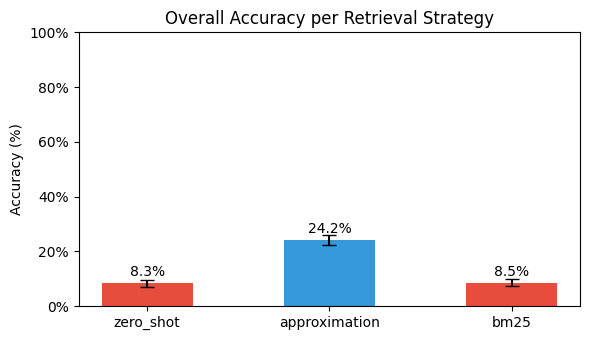

In [4]:
summary_rows = []
for s, df in raw.items():
    n       = len(df)
    n_true  = df["correct"].sum()
    acc     = n_true / n if n else float("nan")
    se      = np.sqrt(acc * (1 - acc) / n) if n else float("nan")
    summary_rows.append({
        "strategy":      s,
        "n":             n,
        "n_correct":     int(n_true),
        "accuracy":      acc,
        "ci95":          1.96 * se,
        "pct_correct":   f"{acc * 100:.1f}%",
    })

summary_df = pd.DataFrame(summary_rows).set_index("strategy")
display(summary_df[["n", "n_correct", "pct_correct", "accuracy", "ci95"]])

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = ["#3498db" if s in ("approximation", "vector") else "#e74c3c" for s in summary_df.index]
bars = ax.bar(summary_df.index, summary_df["accuracy"] * 100, color=colors,
              yerr=summary_df["ci95"] * 100, capsize=5, width=0.5)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Overall Accuracy per Retrieval Strategy")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, row in zip(bars, summary_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{row.accuracy * 100:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_overall_accuracy.png", dpi=150)
plt.show()

## 3. Per-Decile Accuracy — Popularity Bias

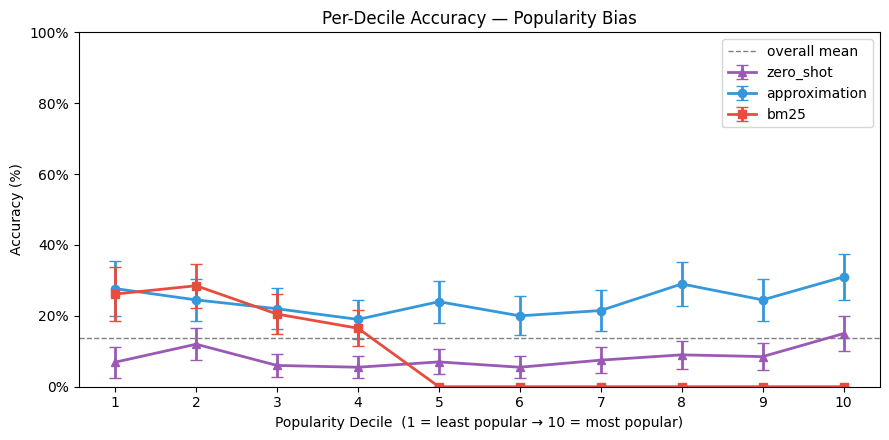


--- zero_shot ---


,accuracy,ci95,n
decile,,,
1,6.9%,±4.4%,130
2,12.0%,±4.5%,200
3,6.0%,±3.3%,200
4,5.5%,±3.2%,200
5,7.0%,±3.5%,200
6,5.5%,±3.2%,200
7,7.5%,±3.7%,200
8,9.0%,±4.0%,200
9,8.5%,±3.9%,200



--- approximation ---


,accuracy,ci95,n
decile,,,
1,27.7%,±7.7%,130
2,24.5%,±6.0%,200
3,22.0%,±5.7%,200
4,19.0%,±5.4%,200
5,24.0%,±5.9%,200
6,20.0%,±5.5%,200
7,21.5%,±5.7%,200
8,29.0%,±6.3%,200
9,24.5%,±6.0%,200



--- bm25 ---


,accuracy,ci95,n
decile,,,
1,26.2%,±7.6%,130
2,28.5%,±6.3%,200
3,20.5%,±5.6%,200
4,16.5%,±5.1%,200
5,0.0%,±0.0%,200
6,0.0%,±0.0%,200
7,0.0%,±0.0%,200
8,0.0%,±0.0%,200
9,0.0%,±0.0%,200


In [5]:
strategy_colors = {
    "approximation": "#3498db",
    "vector":        "#3498db",
    "bm25":          "#e74c3c",
    "zero_shot":    "#9b59b6",
    "hybrid":        "#27ae60",
}
strategy_markers = {
    "approximation": "o",
    "vector":        "o",
    "bm25":          "s",
    "zero_shot":    "^",
    "hybrid":        "D",
}

fig, ax = plt.subplots(figsize=(9, 4.5))

decile_tables: dict[str, pd.DataFrame] = {}

for s, df in raw.items():
    df_valid = df.dropna(subset=["decile"]).copy()
    df_valid["decile"] = df_valid["decile"].astype(int)

    rows = []
    for d in range(NUM_DECILES):
        sub  = df_valid[df_valid["decile"] == d]
        n    = len(sub)
        if n == 0:
            rows.append({"decile": d + 1, "accuracy": np.nan, "ci95": np.nan, "n": 0})
            continue
        acc  = sub["correct"].mean()
        se   = np.sqrt(acc * (1 - acc) / n) if n > 1 else 0.0
        rows.append({"decile": d + 1, "accuracy": acc, "ci95": 1.96 * se, "n": n})

    dt = pd.DataFrame(rows)
    decile_tables[s] = dt

    color  = strategy_colors.get(s, "#888")
    marker = strategy_markers.get(s, "o")
    ax.errorbar(
        dt["decile"], dt["accuracy"] * 100,
        yerr=dt["ci95"] * 100,
        label=s, color=color, marker=marker,
        linewidth=2, markersize=6, capsize=4,
    )

ax.set_xlabel("Popularity Decile  (1 = least popular → 10 = most popular)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Decile Accuracy — Popularity Bias")
ax.set_xticks(range(1, NUM_DECILES + 1))
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.axhline(combined["correct"].mean() * 100, color="grey", linestyle="--",
           linewidth=1, label="overall mean")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_decile_accuracy.png", dpi=150)
plt.show()

# Print table
for s, dt in decile_tables.items():
    print(f"\n--- {s} ---")
    display(dt.set_index("decile").style.format({"accuracy": "{:.1%}", "ci95": "±{:.1%}", "n": "{:,.0f}"}))

## 4. Retrieval Quality — Recall@K

Uses `retrieved_doc_ids` from the result metadata to check whether the target
document (`wikipedia_id`) appeared in the retrieved set — independently of
whether the LLM answer was judged correct.

* **Hit@K** — 1 if the target doc is among the top-K retrieved IDs, else 0.  
  Because the pipeline writes all retrieved IDs into `retrieved_doc_ids`, hit
  is computed directly from that list (no re-truncation at K needed unless you
  want to simulate lower K values).  
* **Per-decile Recall** — shows whether the retriever surfaces documents from
  less-popular deciles as reliably as popular ones.

[zero_shot] No retrieved_doc_ids found in metadata — skipping retrieval analysis.
      Make sure the pipeline writes 'retrieved_doc_ids' into the metadata dict.


,n,hits,pct_hit,recall,ci95
strategy,,,,,
approximation,1930,1056,54.7%,0.54715,0.022208
bm25,1930,949,49.2%,0.49171,0.022304


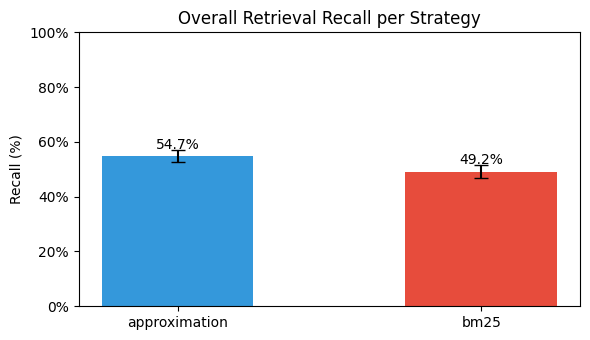

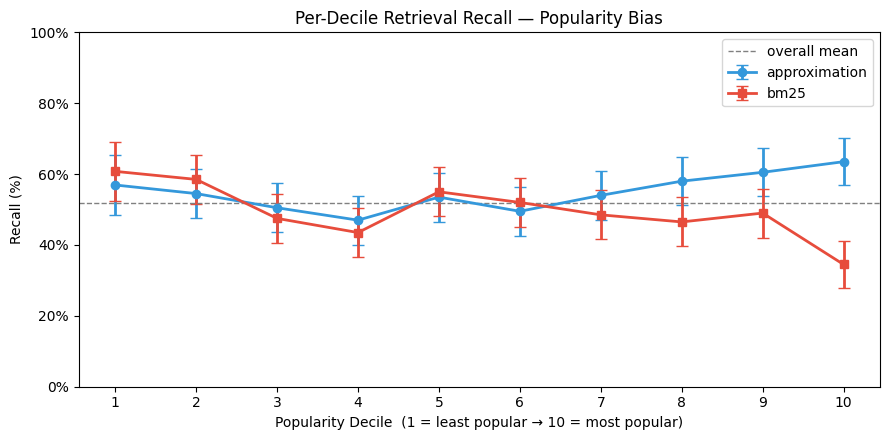

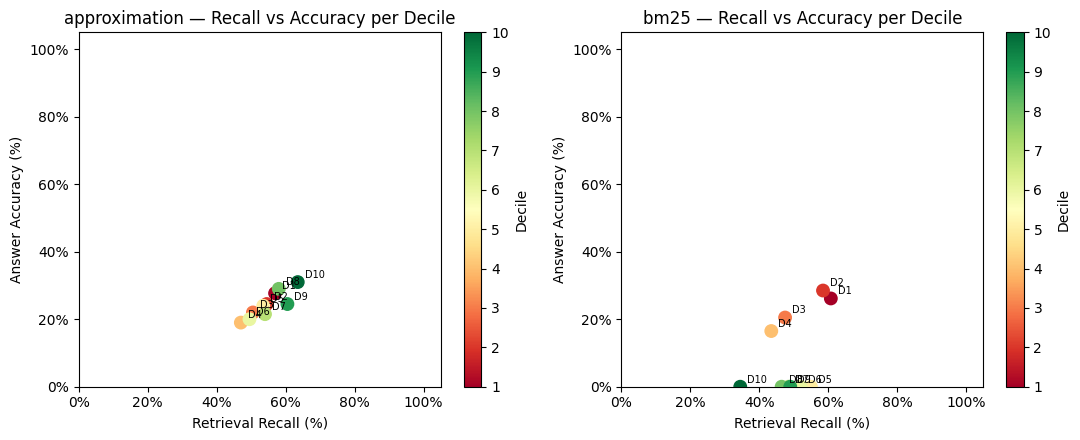


--- approximation ---


,recall,ci95,n
decile,,,
1,56.9%,±8.5%,130
2,54.5%,±6.9%,200
3,50.5%,±6.9%,200
4,47.0%,±6.9%,200
5,53.5%,±6.9%,200
6,49.5%,±6.9%,200
7,54.0%,±6.9%,200
8,58.0%,±6.8%,200
9,60.5%,±6.8%,200



--- bm25 ---


,recall,ci95,n
decile,,,
1,60.8%,±8.4%,130
2,58.5%,±6.8%,200
3,47.5%,±6.9%,200
4,43.5%,±6.9%,200
5,55.0%,±6.9%,200
6,52.0%,±6.9%,200
7,48.5%,±6.9%,200
8,46.5%,±6.9%,200
9,49.0%,±6.9%,200


In [6]:
# ── Retrieval hit rate ────────────────────────────────────────────────────────

# Overall hit rate per strategy
retrieval_summary_rows = []
for s, df in raw.items():
    has_ids = df["retrieved_doc_ids"].apply(bool).sum()
    if has_ids == 0:
        print(f"[{s}] No retrieved_doc_ids found in metadata — skipping retrieval analysis.")
        print("      Make sure the pipeline writes 'retrieved_doc_ids' into the metadata dict.")
        continue
    n    = len(df)
    hits = df["hit"].sum()
    rate = hits / n if n else float("nan")
    se   = np.sqrt(rate * (1 - rate) / n) if n else float("nan")
    retrieval_summary_rows.append({
        "strategy":  s,
        "n":         n,
        "hits":      int(hits),
        "recall": rate,
        "ci95":      1.96 * se,
        "pct_hit":   f"{rate * 100:.1f}%",
    })

if not retrieval_summary_rows:
    print("No retrieval data available — section skipped.")
else:
    ret_summary_df = pd.DataFrame(retrieval_summary_rows).set_index("strategy")
    display(ret_summary_df[["n", "hits", "pct_hit", "recall", "ci95"]])

    # ── Bar chart: overall retrieval recall ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 3.5))
    colors = [strategy_colors.get(s, "#888") for s in ret_summary_df.index]
    bars = ax.bar(
        ret_summary_df.index, ret_summary_df["recall"] * 100,
        color=colors, yerr=ret_summary_df["ci95"] * 100,
        capsize=5, width=0.5,
    )
    ax.set_ylabel("Recall (%)")
    ax.set_title("Overall Retrieval Recall per Strategy")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    for bar, row in zip(bars, ret_summary_df.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{row.recall * 100:.1f}%",
            ha="center", va="bottom", fontsize=10,
        )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_retrieval_recall.png", dpi=150)
    plt.show()

    # ── Per-decile retrieval recall ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4.5))
    decile_recall_tables: dict[str, pd.DataFrame] = {}

    for s, df in raw.items():
        if not df["retrieved_doc_ids"].apply(bool).sum():
            continue
        df_valid = df.dropna(subset=["decile"]).copy()
        df_valid["decile"] = df_valid["decile"].astype(int)

        rows = []
        for d in range(NUM_DECILES):
            sub = df_valid[df_valid["decile"] == d]
            n   = len(sub)
            if n == 0:
                rows.append({"decile": d + 1, "recall": np.nan, "ci95": np.nan, "n": 0})
                continue
            rate = sub["hit"].mean()
            se   = np.sqrt(rate * (1 - rate) / n) if n > 1 else 0.0
            rows.append({"decile": d + 1, "recall": rate, "ci95": 1.96 * se, "n": n})

        drt = pd.DataFrame(rows)
        decile_recall_tables[s] = drt

        color  = strategy_colors.get(s, "#888")
        marker = strategy_markers.get(s, "o")
        ax.errorbar(
            drt["decile"], drt["recall"] * 100,
            yerr=drt["ci95"] * 100,
            label=s, color=color, marker=marker,
            linewidth=2, markersize=6, capsize=4,
        )

    ax.set_xlabel("Popularity Decile  (1 = least popular \u2192 10 = most popular)")
    ax.set_ylabel("Recall (%)")
    ax.set_title("Per-Decile Retrieval Recall — Popularity Bias")
    ax.set_xticks(range(1, NUM_DECILES + 1))
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    if decile_recall_tables:
        overall_hit = combined[combined["retrieved_doc_ids"].apply(bool)]["hit"].mean()
        ax.axhline(overall_hit * 100, color="grey", linestyle="--",
                   linewidth=1, label="overall mean")
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_decile_recall.png", dpi=150)
    plt.show()

    # ── Accuracy vs retrieval recall scatter ──────────────────────────────────
    # Shows whether correct answers require a retrieval hit, or the LLM can
    # recover even when the wrong document is retrieved.
    fig, axes = plt.subplots(1, len(decile_recall_tables), figsize=(5.5 * len(decile_recall_tables), 4.5))
    if len(decile_recall_tables) == 1:
        axes = [axes]

    for ax, (s, drt) in zip(axes, decile_recall_tables.items()):
        dt = decile_tables.get(s)
        if dt is None:
            continue
        merged_d = drt.merge(dt, on="decile", suffixes=("_recall", "_acc"))
        sc = ax.scatter(
            merged_d["recall"] * 100,
            merged_d["accuracy"] * 100,
            c=merged_d["decile"],
            cmap="RdYlGn", s=80, zorder=3,
        )
        for _, row in merged_d.iterrows():
            ax.annotate(
                f"D{int(row['decile'])}",
                (row["recall"] * 100, row["accuracy"] * 100),
                textcoords="offset points", xytext=(5, 3), fontsize=7,
            )
        ax.set_xlabel("Retrieval Recall (%)")
        ax.set_ylabel("Answer Accuracy (%)")
        ax.set_title(f"{s} — Recall vs Accuracy per Decile")
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 105)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        plt.colorbar(sc, ax=ax, label="Decile")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_recall_vs_accuracy.png", dpi=150)
    plt.show()

    # ── Per-decile recall tables ──────────────────────────────────────────────
    for s, drt in decile_recall_tables.items():
        print(f"\n--- {s} ---")
        display(
            drt.set_index("decile").style.format(
                {"recall": "{:.1%}", "ci95": "\u00b1{:.1%}", "n": "{:,.0f}"}
            )
        )

## 4b. Retrieval Failure → Output Failure Correlation

For each popularity decile, this section computes the **error rate** (% of
incorrect LLM answers) separately for rows where retrieval **missed** the
target document versus rows where retrieval **hit** it.

A large gap between the two bars shows that wrong retrieval strongly
correlates with wrong output in that decile; a small gap means the LLM can
often compensate even without the correct document.

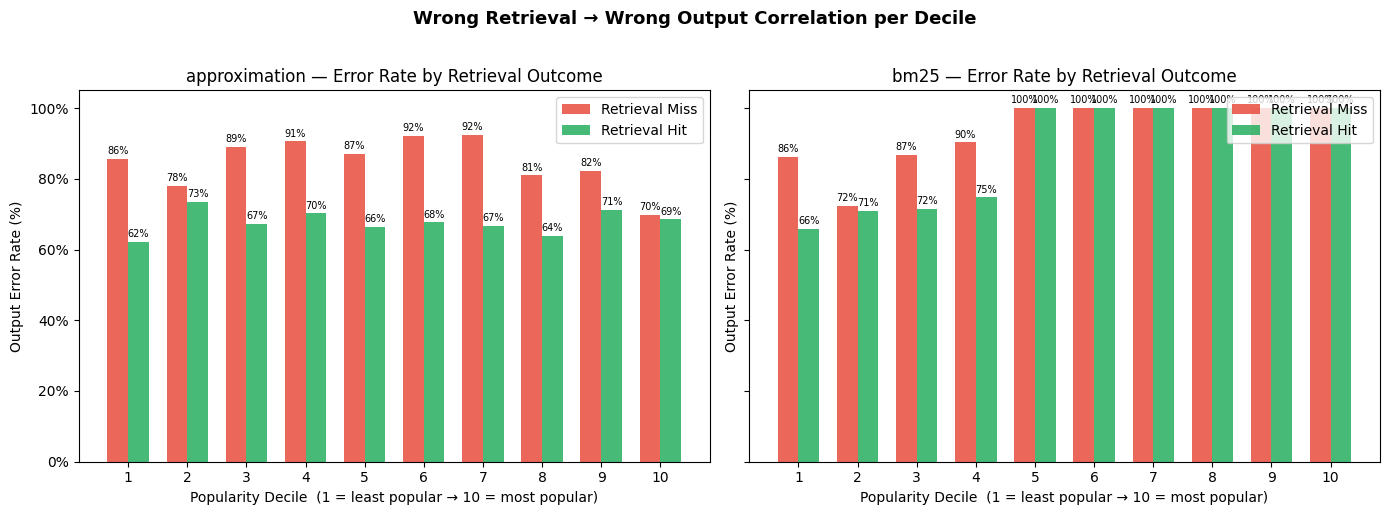


── Conditional error rates (overall, not per-decile) ──
  [approximation]  retrieval-miss error rate: 85.4%  |  retrieval-hit error rate: 67.9%  |  delta: +17.5%
  [bm25]  retrieval-miss error rate: 94.4%  |  retrieval-hit error rate: 88.4%  |  delta: +6.0%


In [7]:
# ── Retrieval-failure → output-failure correlation per decile ────────────────

# Only consider strategies that have retrieval data
_strats_with_retrieval = [
    s for s in LOADED
    if raw[s]["retrieved_doc_ids"].apply(bool).sum() > 0
]

if not _strats_with_retrieval:
    print("No strategies have retrieval data — skipping retrieval-error correlation.")
else:
    n_strats = len(_strats_with_retrieval)
    fig, axes = plt.subplots(1, n_strats, figsize=(7 * n_strats, 5), sharey=True)
    if n_strats == 1:
        axes = [axes]

    for ax, s in zip(axes, _strats_with_retrieval):
        df = raw[s].dropna(subset=["decile"]).copy()
        df["decile"] = df["decile"].astype(int)

        rows = []
        for d in range(NUM_DECILES):
            sub = df[df["decile"] == d]
            for hit_val, label in [(False, "Retrieval Miss"), (True, "Retrieval Hit")]:
                group = sub[sub["hit"] == hit_val]
                n = len(group)
                if n == 0:
                    err_rate = np.nan
                else:
                    err_rate = (~group["correct"]).mean()
                rows.append({
                    "decile": d + 1,
                    "retrieval": label,
                    "error_rate": err_rate,
                    "n": n,
                })

        corr_df = pd.DataFrame(rows)

        deciles = list(range(1, NUM_DECILES + 1))
        bar_width = 0.35
        x = np.arange(len(deciles))

        miss_df = corr_df[corr_df["retrieval"] == "Retrieval Miss"]
        hit_df  = corr_df[corr_df["retrieval"] == "Retrieval Hit"]

        bars_miss = ax.bar(
            x - bar_width / 2,
            miss_df["error_rate"].values * 100,
            bar_width,
            label="Retrieval Miss",
            color="#e74c3c",
            alpha=0.85,
        )
        bars_hit = ax.bar(
            x + bar_width / 2,
            hit_df["error_rate"].values * 100,
            bar_width,
            label="Retrieval Hit",
            color="#27ae60",
            alpha=0.85,
        )

        # Annotate bar values
        for bars in [bars_miss, bars_hit]:
            for bar in bars:
                h = bar.get_height()
                if not np.isnan(h) and h > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2, h + 0.8,
                        f"{h:.0f}%", ha="center", va="bottom", fontsize=7,
                    )

        ax.set_xticks(x)
        ax.set_xticklabels(deciles)
        ax.set_xlabel("Popularity Decile  (1 = least popular \u2192 10 = most popular)")
        ax.set_ylabel("Output Error Rate (%)")
        ax.set_title(f"{s} — Error Rate by Retrieval Outcome")
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend(loc="upper right")

    plt.suptitle(
        "Wrong Retrieval → Wrong Output Correlation per Decile",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_retrieval_error_correlation.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Summary table: per-strategy conditional error rates ────────────────────
    print("\n── Conditional error rates (overall, not per-decile) ──")
    for s in _strats_with_retrieval:
        df = raw[s]
        miss = df[~df["hit"]]
        hit  = df[df["hit"]]
        miss_err = (~miss["correct"]).mean() if len(miss) else float("nan")
        hit_err  = (~hit["correct"]).mean()  if len(hit)  else float("nan")
        print(f"  [{s}]  retrieval-miss error rate: {miss_err:.1%}  |  "
              f"retrieval-hit error rate: {hit_err:.1%}  |  "
              f"delta: {miss_err - hit_err:+.1%}")

## 4c. Popularity Skew in Retrieval Errors

When the system retrieves the **wrong** document, is that document typically
**more popular** than the intended target?  For each decile we compute the
fraction of *incorrectly answered* questions where the most-popular retrieved
document had higher popularity than the target document.

A high fraction in the lower deciles (unpopular articles) would confirm that
the retriever systematically substitutes more-popular documents — a direct
measure of popularity bias in the retrieval step.

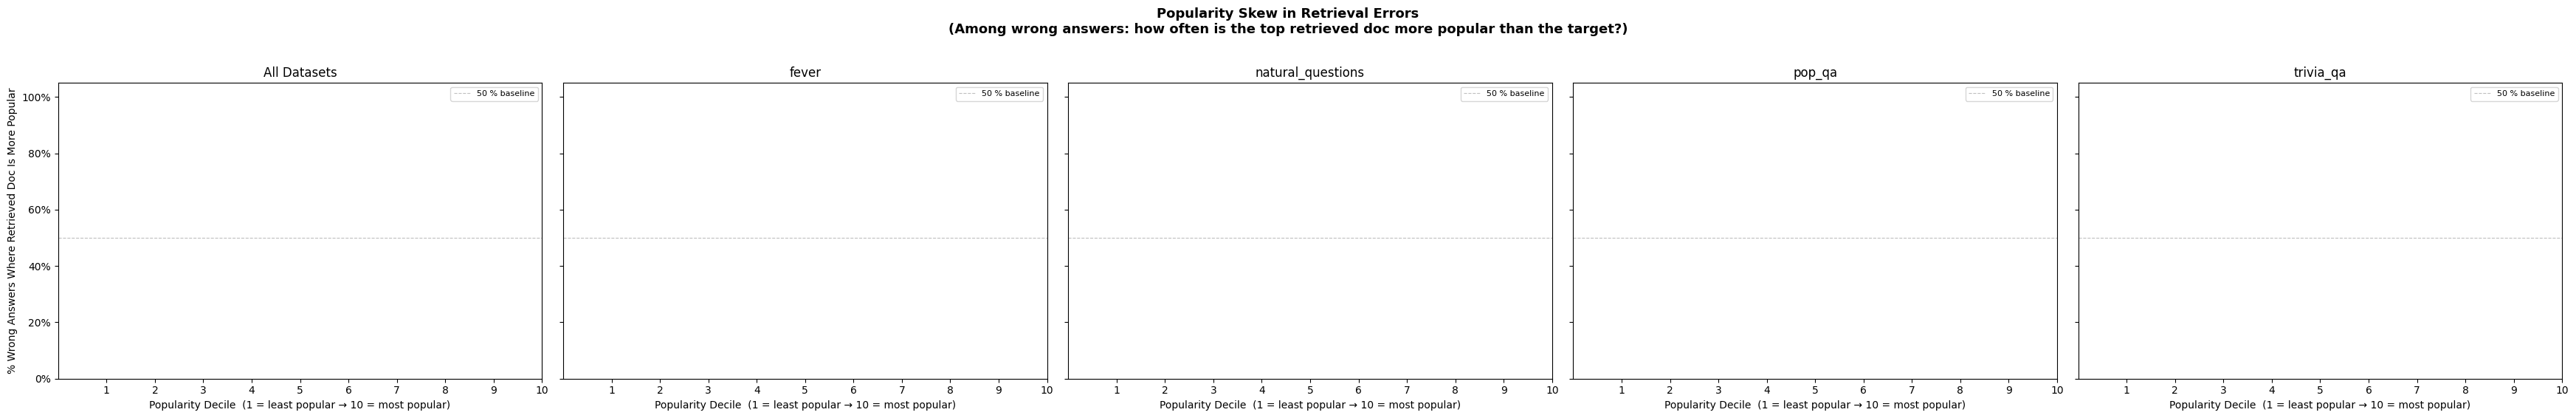


── Popularity skew summary (overall, not per-decile) ──
  [approximation]  no wrong answers with retrieval data
  [bm25]  no wrong answers with retrieval data


In [8]:
# ── Popularity skew in retrieval errors per decile ─────────────────────────────

_strats_retrieval = [
    s for s in LOADED
    if raw[s]["retrieved_doc_ids"].apply(bool).sum() > 0
]

if not _strats_retrieval:
    print("No strategies have retrieval data — skipping popularity-skew analysis.")
else:
    # Collect all datasets across strategies with retrieval data
    _all_datasets = sorted(
        combined[combined["strategy"].isin(_strats_retrieval)]["dataset"]
        .dropna().unique()
    )
    # First panel = "All datasets" combined, then one panel per dataset
    _panel_labels = ["All Datasets"] + list(_all_datasets)
    ncols = len(_panel_labels)

    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5.5), sharey=True)
    if ncols == 1:
        axes = [axes]

    def _plot_skew(ax, data_df, title):
        """Plot popularity-skew lines for each strategy on a single axes."""
        for s in _strats_retrieval:
            df = data_df[data_df["strategy"] == s].copy()
            df = df.dropna(subset=["decile", "popularity_avg"])
            if df.empty:
                continue
            df["decile"] = df["decile"].astype(int)

            # Only rows answered incorrectly AND that have retrieval data
            wrong = df[
                (~df["correct"]) & (df["retrieved_doc_popularity"].apply(len) > 0)
            ].copy()

            if wrong.empty:
                continue

            wrong["max_ret_pop"] = wrong["retrieved_doc_popularity"].apply(max)
            wrong["ret_more_popular"] = wrong["max_ret_pop"] > wrong["popularity_avg"]

            rows = []
            for d in range(NUM_DECILES):
                sub = wrong[wrong["decile"] == d]
                n = len(sub)
                frac = sub["ret_more_popular"].mean() if n > 0 else np.nan
                rows.append({"decile": d + 1, "frac_more_popular": frac, "n": n})

            skew_df = pd.DataFrame(rows)

            color = strategy_colors.get(s, "#555555")
            marker = strategy_markers.get(s, "o")
            ax.plot(
                skew_df["decile"], skew_df["frac_more_popular"] * 100,
                marker=marker, color=color, linewidth=2, markersize=8,
                label=s,
            )

            # Annotate sample sizes
            for _, r in skew_df.iterrows():
                if not np.isnan(r["frac_more_popular"]):
                    ax.annotate(
                        f'n={r["n"]:.0f}',
                        (r["decile"], r["frac_more_popular"] * 100),
                        textcoords="offset points", xytext=(0, 10),
                        fontsize=7, ha="center", color="#666666",
                    )

        ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, alpha=0.5, label="50 % baseline")
        ax.set_xticks(range(1, NUM_DECILES + 1))
        ax.set_xlabel("Popularity Decile  (1 = least popular \u2192 10 = most popular)")
        ax.set_title(title)
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend(loc="upper right", fontsize=8)

    # Build a combined df from strategies that have retrieval data
    _retrieval_combined = pd.concat(
        [raw[s] for s in _strats_retrieval], ignore_index=True
    )

    for ax, panel in zip(axes, _panel_labels):
        if panel == "All Datasets":
            _plot_skew(ax, _retrieval_combined, "All Datasets")
        else:
            _plot_skew(ax, _retrieval_combined[_retrieval_combined["dataset"] == panel], panel)

    axes[0].set_ylabel("% Wrong Answers Where Retrieved Doc Is More Popular")

    plt.suptitle(
        "Popularity Skew in Retrieval Errors\n"
        "(Among wrong answers: how often is the top retrieved doc more popular than the target?)",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_popularity_skew_retrieval_errors.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Summary table ──────────────────────────────────────────────────────────
    print("\n── Popularity skew summary (overall, not per-decile) ──")
    for s in _strats_retrieval:
        df = raw[s].copy()
        df = df.dropna(subset=["popularity_avg"])
        wrong = df[(~df["correct"]) & (df["retrieved_doc_popularity"].apply(len) > 0)]
        if len(wrong) == 0:
            print(f"  [{s}]  no wrong answers with retrieval data")
            continue
        max_pop = wrong["retrieved_doc_popularity"].apply(max)
        frac = (max_pop > wrong["popularity_avg"]).mean()
        print(f"  [{s}]  {frac:.1%} of wrong answers had a more-popular retrieved doc  "
              f"(n={len(wrong)})")

## 4d. Error Composition, Retrieval-Output Correlation, and Popularity Preference

This section adds three diagnostics requested for pipeline debugging:

1. **Error composition**: among all incorrect answers, what fraction came from retrieval misses vs retrieval hits? (overall + per dataset)
2. **Retrieval-output correlation (dataset basis)**: how strongly retrieval miss/hit is associated with wrong/correct answers per dataset
3. **Popularity preference of retrieved docs**: compare preference for **all retrieved docs** vs **wrongly retrieved docs only** (overall + per dataset)



-- Error composition (for 100% of wrong answers) --


,strategy,dataset_scope,n_errors,errors_retrieval_miss,errors_retrieval_hit,pct_errors_retrieval_miss,pct_errors_retrieval_hit
0,approximation,All,1463,746,717,50.991114,49.008886
1,approximation,fever,456,178,278,39.035088,60.964912
2,approximation,natural_questions,380,215,165,56.578947,43.421053
3,approximation,pop_qa,377,216,161,57.294430,42.705570
4,approximation,trivia_qa,250,137,113,54.800000,45.200000
5,bm25,All,1765,926,839,52.464589,47.535411
6,bm25,fever,456,158,298,34.649123,65.350877
7,bm25,natural_questions,466,280,186,60.085837,39.914163
8,bm25,pop_qa,459,307,152,66.884532,33.115468
9,bm25,trivia_qa,384,181,203,47.135417,52.864583


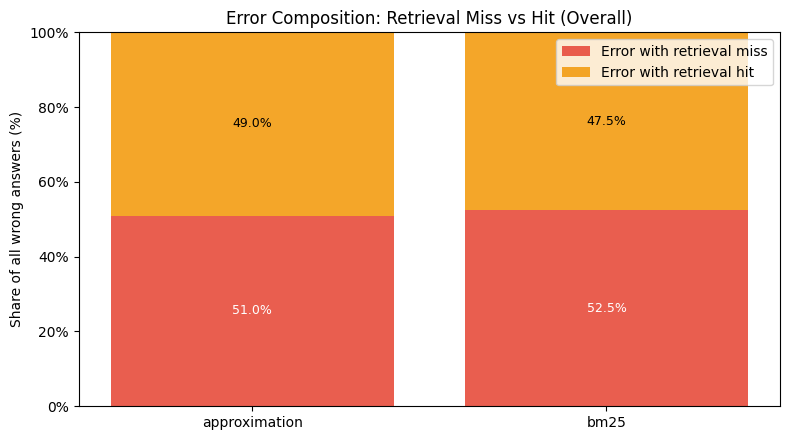

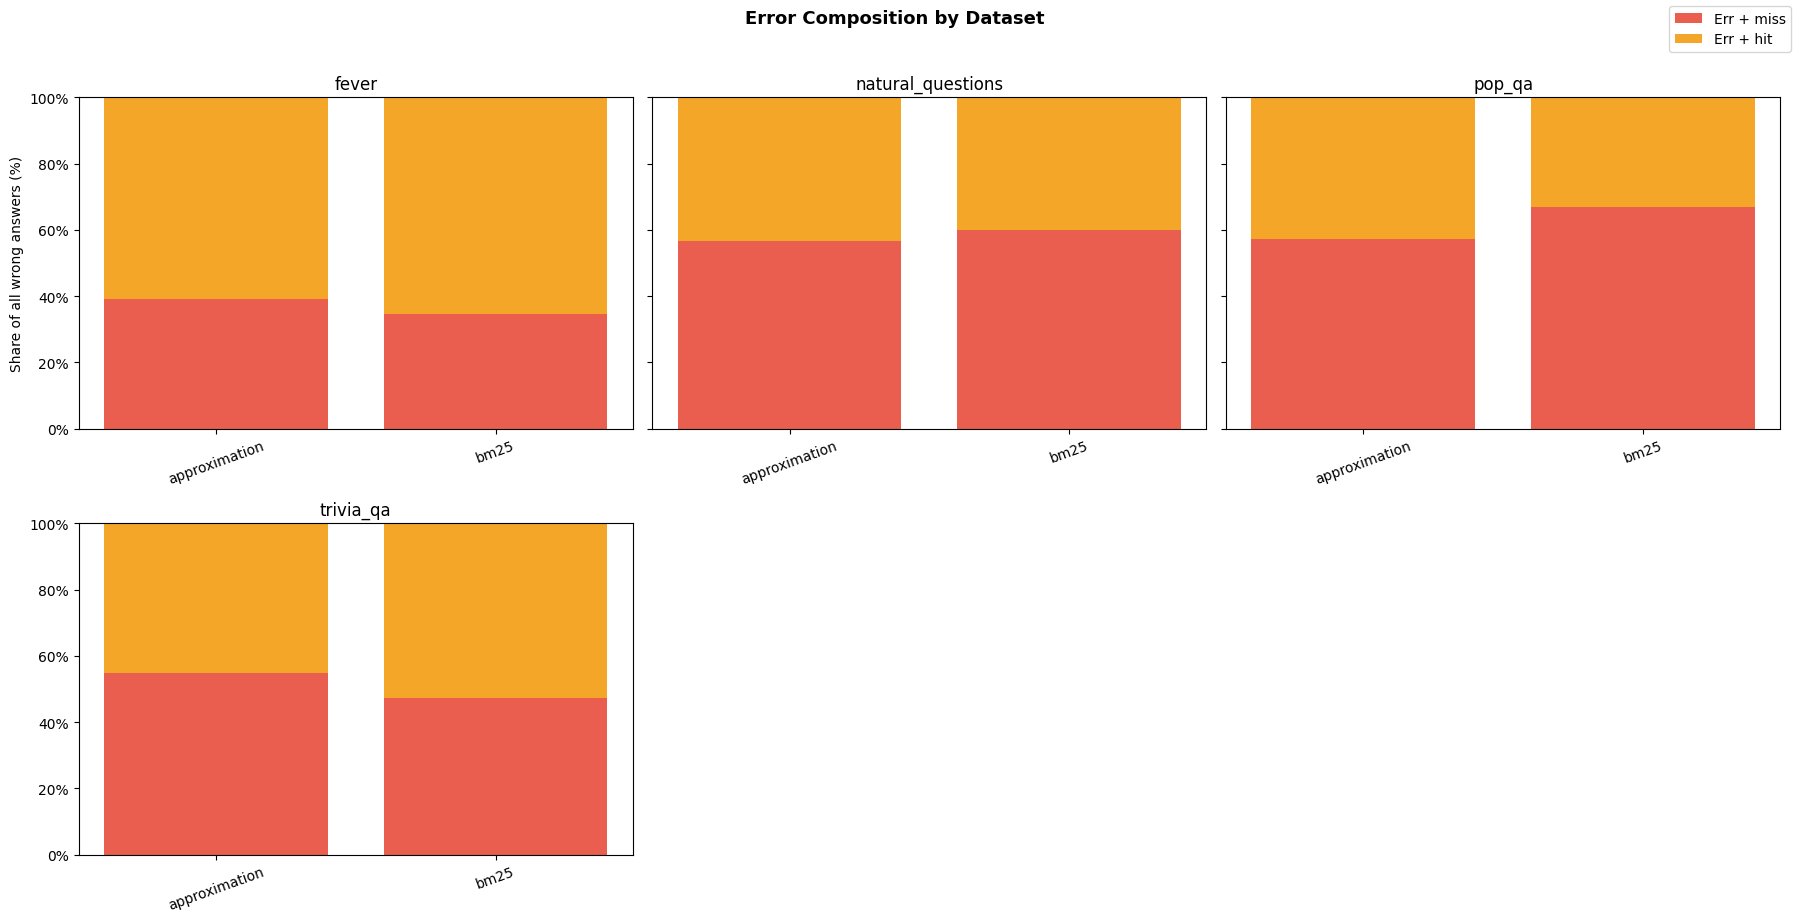


-- Retrieval-output correlation (dataset basis) --


,strategy,dataset_scope,n,n_miss,n_hit,err_rate_given_miss_pct,err_rate_given_hit_pct,delta_miss_minus_hit_pct,phi_hit_correct
0,approximation,All,1930,874,1056,85.354691,67.897727,17.456964,0.202897
1,approximation,fever,456,178,278,100.000000,100.000000,0.000000,NaN
2,approximation,natural_questions,500,248,252,86.693548,65.476190,21.217358,0.248391
3,approximation,pop_qa,500,223,277,96.860987,58.122744,38.738243,0.447104
4,approximation,trivia_qa,474,225,249,60.888889,45.381526,15.507363,0.155108
5,bm25,All,1930,981,949,94.393476,88.408851,5.984625,0.107002
6,bm25,fever,456,158,298,100.000000,100.000000,0.000000,NaN
7,bm25,natural_questions,500,294,206,95.238095,90.291262,4.946833,0.096717
8,bm25,pop_qa,500,310,190,99.032258,80.000000,19.032258,0.336705
9,bm25,trivia_qa,474,219,255,82.648402,79.607843,3.040559,0.038651


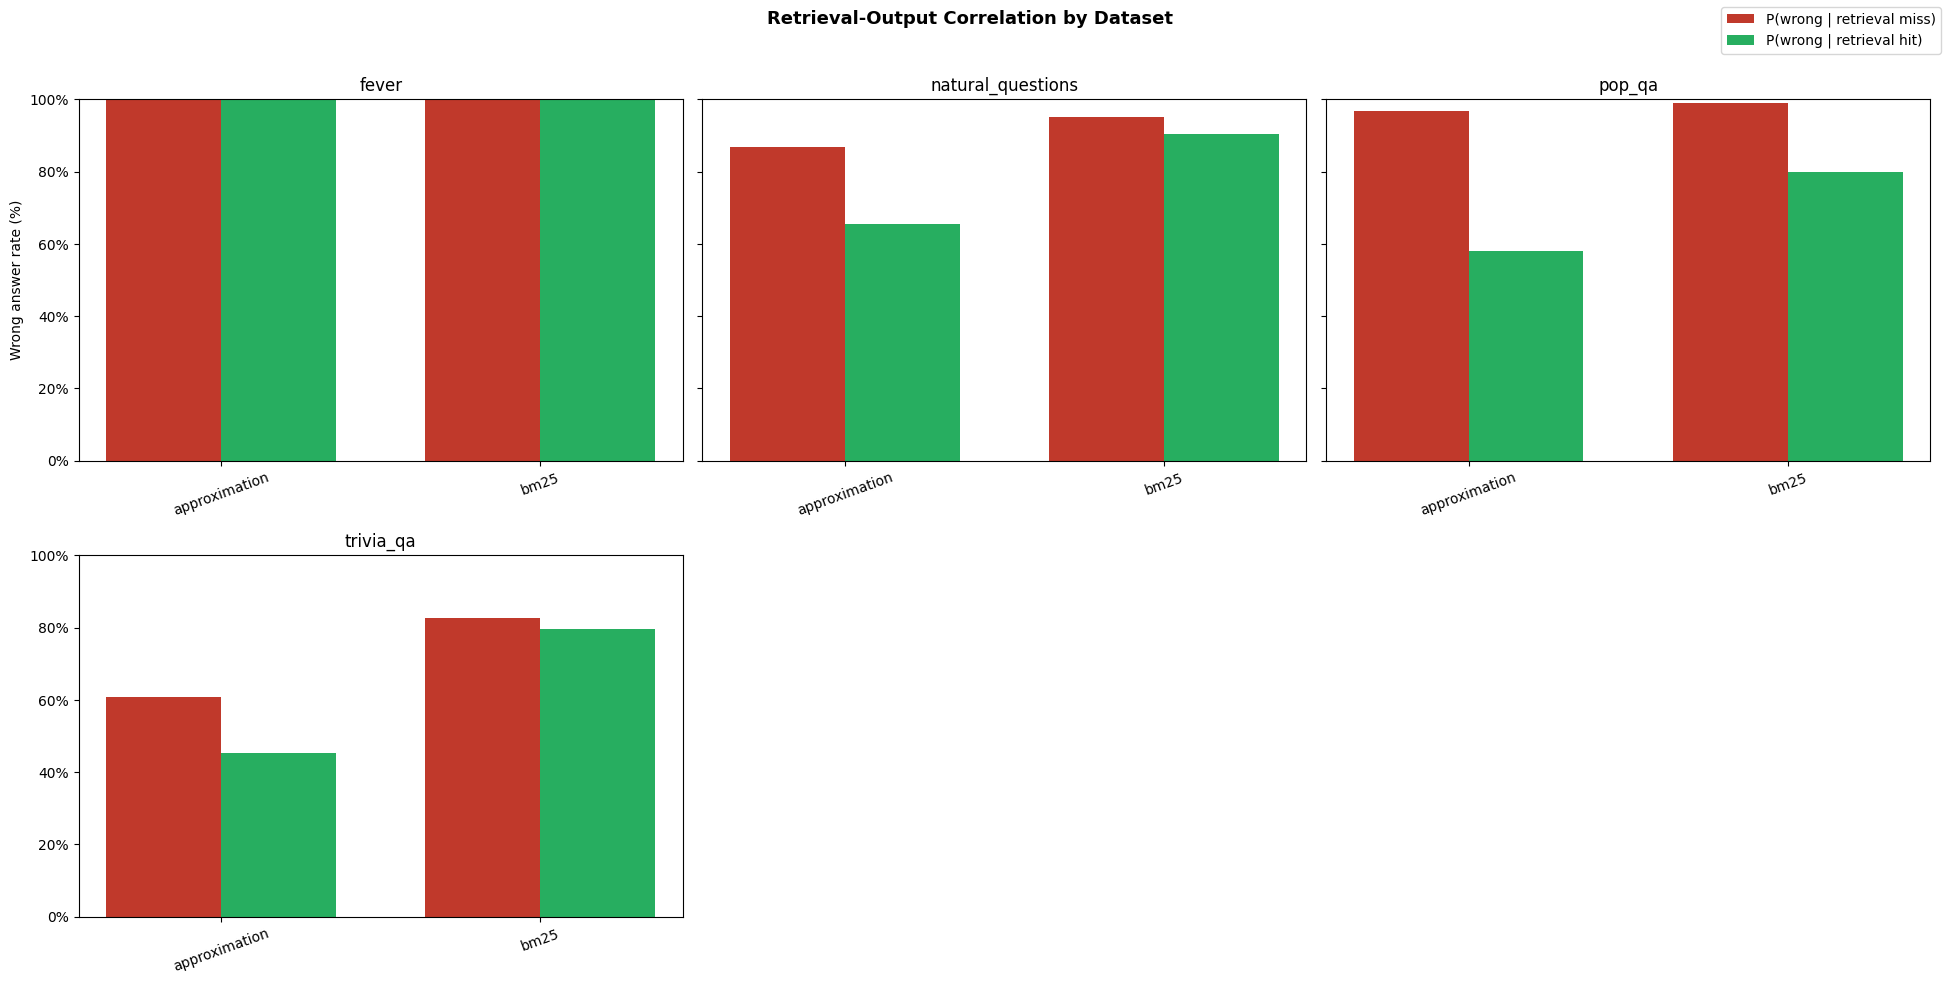


-- Popularity preference: all retrieved docs vs wrongly retrieved docs --


,strategy,dataset_scope,all_retrieved_total,pref_all_retrieved_pct,wrong_retrieved_total,pref_wrong_retrieved_pct
0,approximation,All,0,NaN,0,NaN
1,approximation,fever,0,NaN,0,NaN
2,approximation,natural_questions,0,NaN,0,NaN
3,approximation,pop_qa,0,NaN,0,NaN
4,approximation,trivia_qa,0,NaN,0,NaN
5,bm25,All,0,NaN,0,NaN
6,bm25,fever,0,NaN,0,NaN
7,bm25,natural_questions,0,NaN,0,NaN
8,bm25,pop_qa,0,NaN,0,NaN
9,bm25,trivia_qa,0,NaN,0,NaN


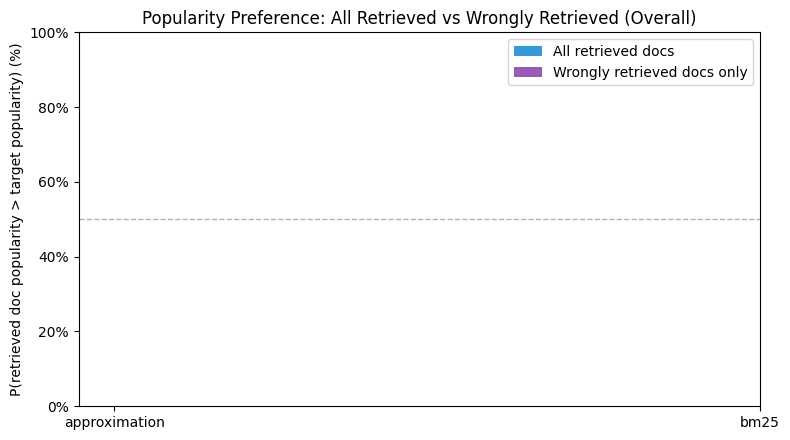

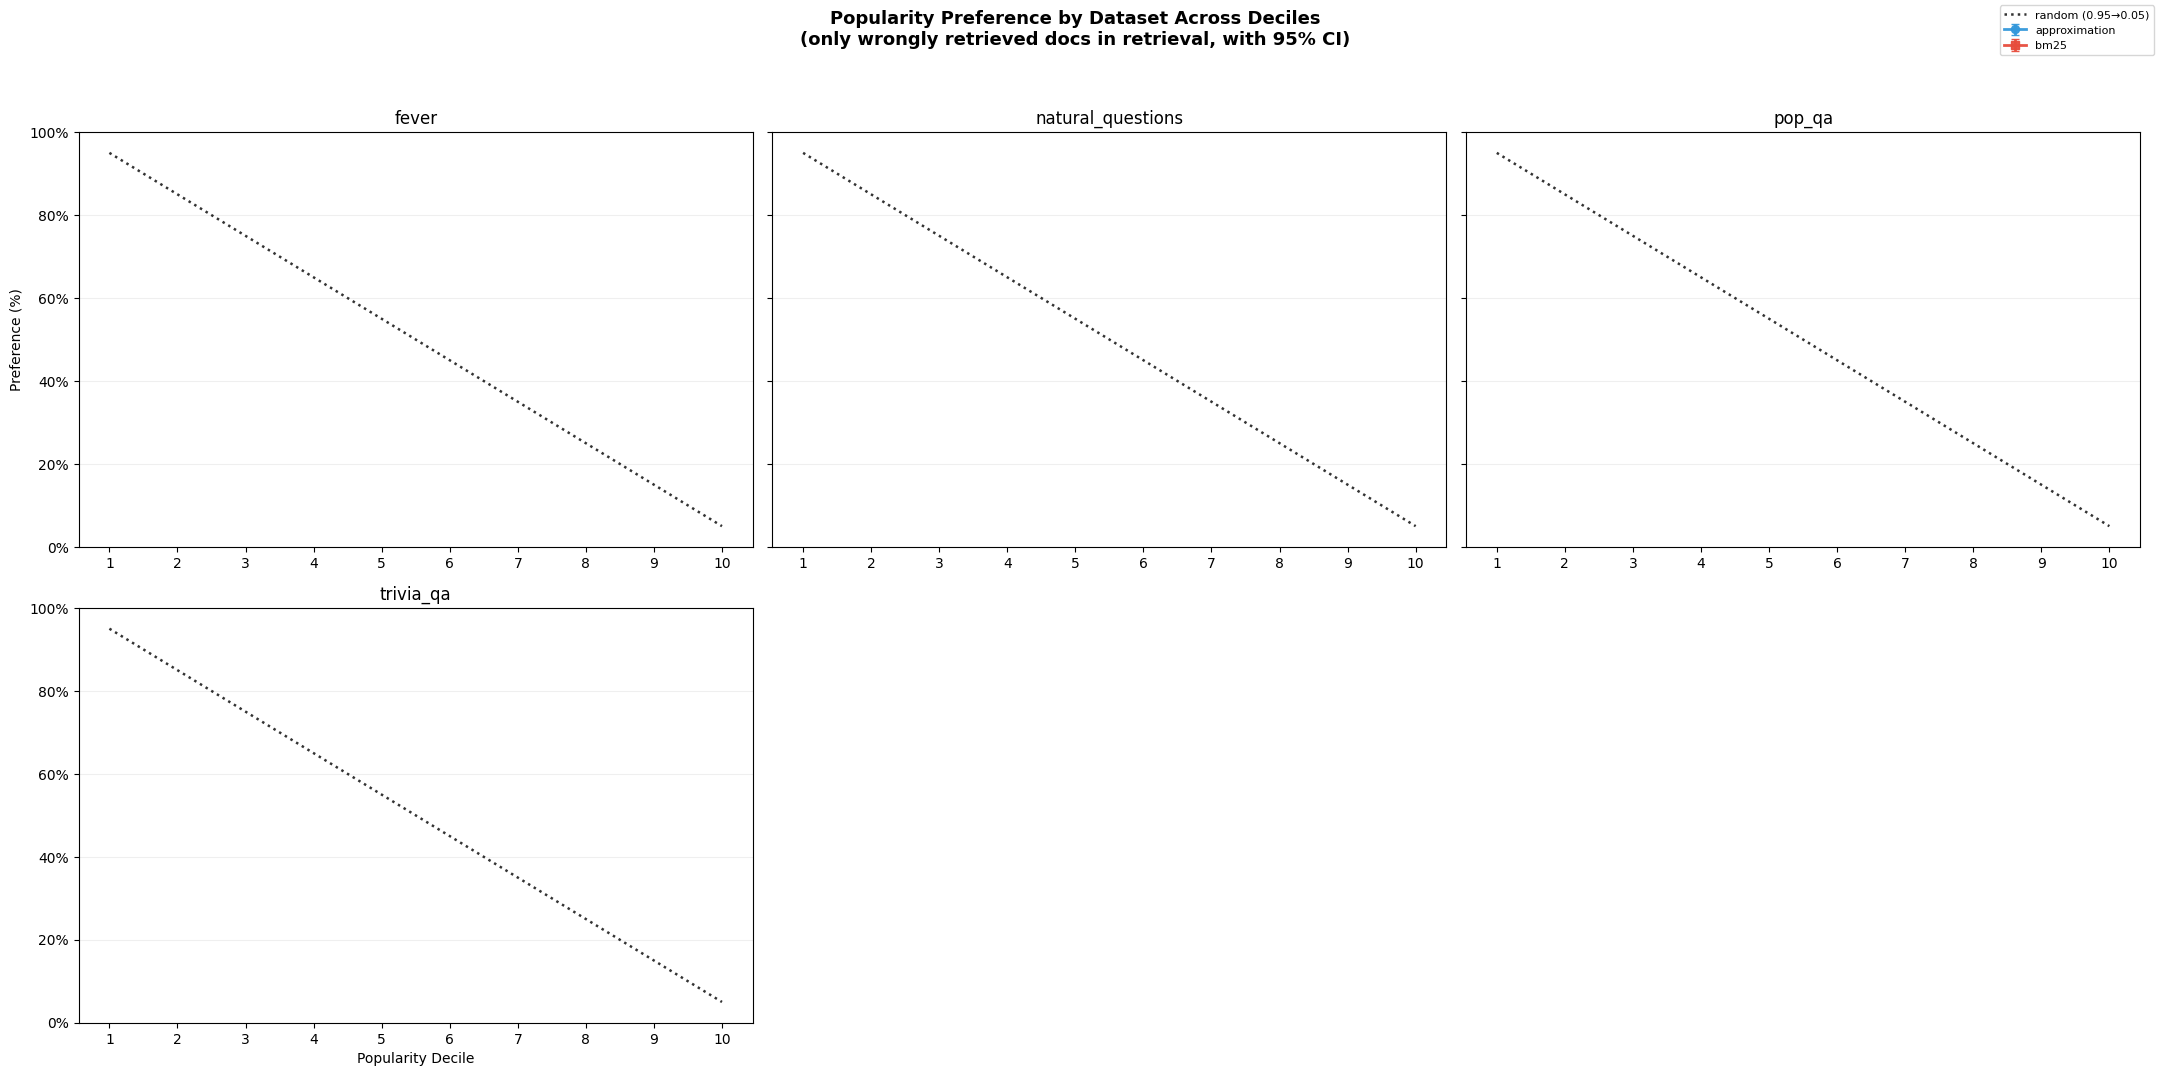

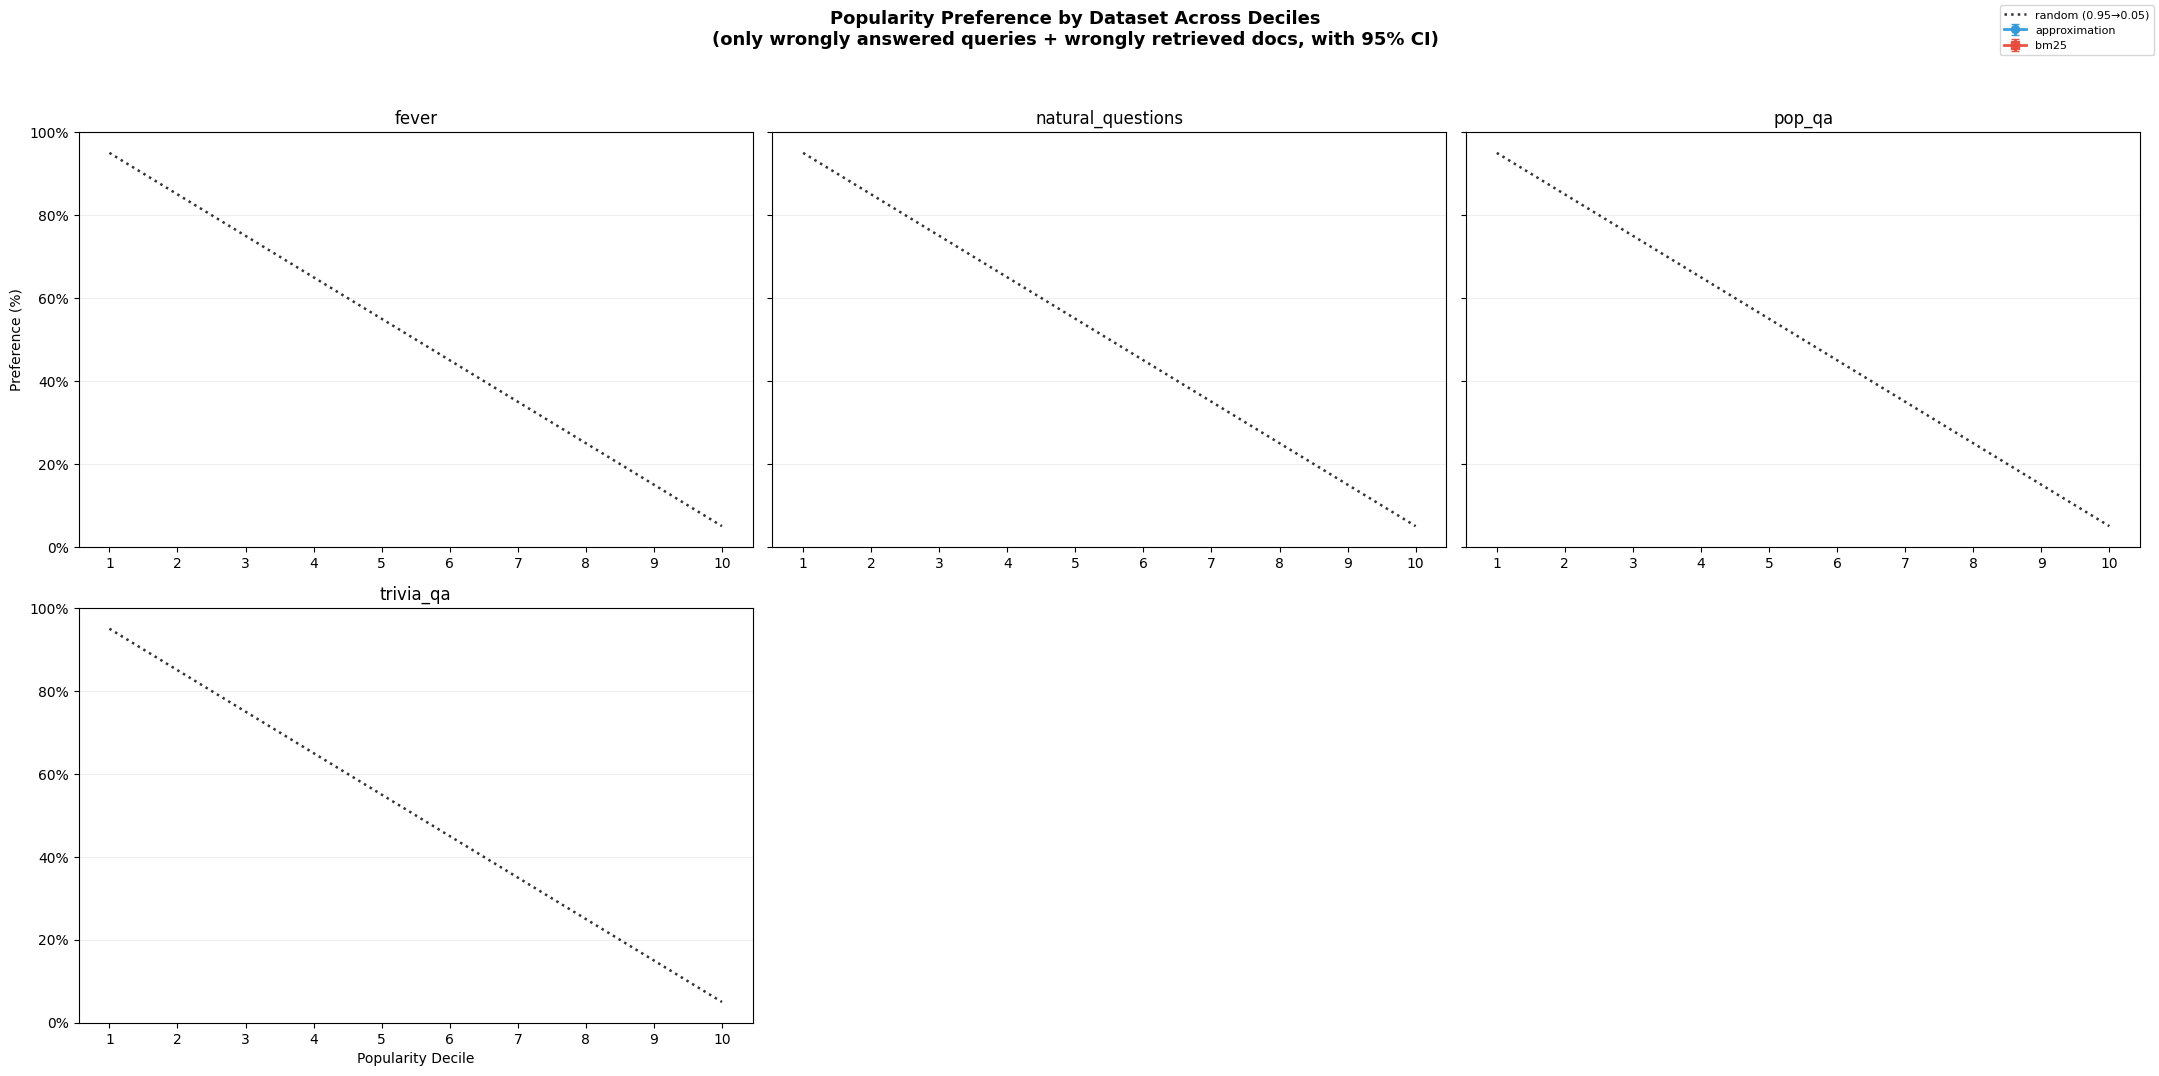

In [9]:
# -- Extra diagnostics requested: error composition, correlation, preference --

_strats_retrieval = [
    s for s in LOADED
    if raw[s]["retrieved_doc_ids"].apply(bool).sum() > 0
]

if not _strats_retrieval:
    print("No strategies have retrieval metadata -- skipping section 4d.")
else:
    # ------------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------------
    def _error_composition_df(df: pd.DataFrame) -> dict[str, float]:
        err = df[~df["correct"]]
        n_err = len(err)
        miss = int((~err["hit"]).sum())
        hit = int(err["hit"].sum())
        miss_pct = (miss / n_err * 100) if n_err else float("nan")
        hit_pct = (hit / n_err * 100) if n_err else float("nan")
        return {
            "n_errors": n_err,
            "errors_retrieval_miss": miss,
            "errors_retrieval_hit": hit,
            "pct_errors_retrieval_miss": miss_pct,
            "pct_errors_retrieval_hit": hit_pct,
        }

    def _corr_stats(df: pd.DataFrame) -> dict[str, float]:
        miss = df[~df["hit"]]
        hit = df[df["hit"]]

        err_given_miss = (~miss["correct"]).mean() * 100 if len(miss) else float("nan")
        err_given_hit = (~hit["correct"]).mean() * 100 if len(hit) else float("nan")

        # phi-like correlation between retrieval hit and correctness
        x = df["hit"].astype(int)
        y = df["correct"].astype(int)
        phi = x.corr(y) if len(df) > 1 else float("nan")

        return {
            "n": len(df),
            "n_hit": int(df["hit"].sum()),
            "n_miss": int((~df["hit"]).sum()),
            "err_rate_given_miss_pct": err_given_miss,
            "err_rate_given_hit_pct": err_given_hit,
            "delta_miss_minus_hit_pct": (err_given_miss - err_given_hit)
            if not np.isnan(err_given_miss) and not np.isnan(err_given_hit)
            else float("nan"),
            "phi_hit_correct": phi,
        }

    def _compute_preference_counts(df: pd.DataFrame) -> dict[str, float]:
        n_all_total = 0
        n_all_higher = 0
        n_wrong_total = 0
        n_wrong_higher = 0

        for _, r in df.iterrows():
            target_pop = r.get("popularity_avg")
            if pd.isna(target_pop):
                continue

            ids = r.get("retrieved_doc_ids", [])
            pops = r.get("retrieved_doc_popularity", [])
            if not isinstance(ids, list) or not isinstance(pops, list) or len(pops) == 0:
                continue

            # All retrieved docs
            for p in pops:
                n_all_total += 1
                if p > target_pop:
                    n_all_higher += 1

            # Wrongly retrieved docs only (id != target wikipedia_id)
            target_id = r.get("wikipedia_id_int")
            if pd.isna(target_id):
                continue
            target_id = int(target_id)

            for doc_id, p in zip(ids, pops):
                if int(doc_id) != target_id:
                    n_wrong_total += 1
                    if p > target_pop:
                        n_wrong_higher += 1

        pref_all = (n_all_higher / n_all_total * 100) if n_all_total else float("nan")
        pref_wrong = (n_wrong_higher / n_wrong_total * 100) if n_wrong_total else float("nan")

        return {
            "all_retrieved_total": n_all_total,
            "all_retrieved_more_popular": n_all_higher,
            "pref_all_retrieved_pct": pref_all,
            "wrong_retrieved_total": n_wrong_total,
            "wrong_retrieved_more_popular": n_wrong_higher,
            "pref_wrong_retrieved_pct": pref_wrong,
        }

    # Datasets seen in retrieval-enabled strategies
    _datasets = sorted(
        combined[combined["strategy"].isin(_strats_retrieval)]["dataset"].dropna().unique()
    )

    # ------------------------------------------------------------------
    # (1) Error composition: among errors, retrieval miss vs hit
    # ------------------------------------------------------------------
    err_rows = []
    for s in _strats_retrieval:
        df_s = raw[s]

        # Overall
        overall = _error_composition_df(df_s)
        err_rows.append({"strategy": s, "dataset_scope": "All", **overall})

        # Per dataset
        for ds in _datasets:
            sub = df_s[df_s["dataset"] == ds]
            stats = _error_composition_df(sub)
            err_rows.append({"strategy": s, "dataset_scope": ds, **stats})

    err_comp_df = pd.DataFrame(err_rows)

    print("\n-- Error composition (for 100% of wrong answers) --")
    display(
        err_comp_df[
            [
                "strategy",
                "dataset_scope",
                "n_errors",
                "errors_retrieval_miss",
                "errors_retrieval_hit",
                "pct_errors_retrieval_miss",
                "pct_errors_retrieval_hit",
            ]
        ]
    )

    # Overall stacked bars
    overall_err = err_comp_df[err_comp_df["dataset_scope"] == "All"].set_index("strategy")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(overall_err))
    miss_vals = overall_err["pct_errors_retrieval_miss"].values
    hit_vals = overall_err["pct_errors_retrieval_hit"].values

    bars1 = ax.bar(x, miss_vals, label="Error with retrieval miss", color="#e74c3c", alpha=0.9)
    bars2 = ax.bar(x, hit_vals, bottom=miss_vals, label="Error with retrieval hit", color="#f39c12", alpha=0.9)

    for i, (m, h) in enumerate(zip(miss_vals, hit_vals)):
        if not np.isnan(m):
            ax.text(i, m / 2, f"{m:.1f}%", ha="center", va="center", fontsize=9, color="white")
        if not np.isnan(h):
            ax.text(i, m + h / 2, f"{h:.1f}%", ha="center", va="center", fontsize=9, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(overall_err.index)
    ax.set_ylabel("Share of all wrong answers (%)")
    ax.set_title("Error Composition: Retrieval Miss vs Hit (Overall)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_error_composition_overall.png", dpi=150)
    plt.show()

    # Per-dataset grouped stacked bars
    if _datasets:
        n_cols = min(3, len(_datasets))
        n_rows = int(np.ceil(len(_datasets) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), squeeze=False, sharey=True)

        for idx, ds in enumerate(_datasets):
            r, c = divmod(idx, n_cols)
            ax = axes[r, c]
            sub = err_comp_df[err_comp_df["dataset_scope"] == ds].set_index("strategy").reindex(_strats_retrieval)
            x = np.arange(len(sub))
            miss_vals = sub["pct_errors_retrieval_miss"].values
            hit_vals = sub["pct_errors_retrieval_hit"].values

            ax.bar(x, miss_vals, label="Err + miss", color="#e74c3c", alpha=0.9)
            ax.bar(x, hit_vals, bottom=miss_vals, label="Err + hit", color="#f39c12", alpha=0.9)
            ax.set_xticks(x)
            ax.set_xticklabels(sub.index, rotation=20)
            ax.set_title(ds)
            ax.set_ylim(0, 100)
            ax.yaxis.set_major_formatter(mticker.PercentFormatter())

        for idx in range(len(_datasets), n_rows * n_cols):
            r, c = divmod(idx, n_cols)
            axes[r, c].axis("off")

        axes[0, 0].set_ylabel("Share of all wrong answers (%)")
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right")
        fig.suptitle("Error Composition by Dataset", fontsize=13, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "fig_error_composition_by_dataset.png", dpi=150, bbox_inches="tight")
        plt.show()

    # ------------------------------------------------------------------
    # (2) Retrieval-output correlation on dataset basis
    # ------------------------------------------------------------------
    corr_rows = []
    for s in _strats_retrieval:
        df_s = raw[s]
        corr_rows.append({"strategy": s, "dataset_scope": "All", **_corr_stats(df_s)})
        for ds in _datasets:
            sub = df_s[df_s["dataset"] == ds]
            corr_rows.append({"strategy": s, "dataset_scope": ds, **_corr_stats(sub)})

    corr_df = pd.DataFrame(corr_rows)

    print("\n-- Retrieval-output correlation (dataset basis) --")
    display(
        corr_df[
            [
                "strategy",
                "dataset_scope",
                "n",
                "n_miss",
                "n_hit",
                "err_rate_given_miss_pct",
                "err_rate_given_hit_pct",
                "delta_miss_minus_hit_pct",
                "phi_hit_correct",
            ]
        ]
    )

    # Plot per-dataset: wrong answer rate conditioned on miss/hit
    if _datasets:
        n_cols = min(3, len(_datasets))
        n_rows = int(np.ceil(len(_datasets) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 4.8 * n_rows), squeeze=False, sharey=True)

        for idx, ds in enumerate(_datasets):
            r, c = divmod(idx, n_cols)
            ax = axes[r, c]
            sub = corr_df[corr_df["dataset_scope"] == ds].set_index("strategy").reindex(_strats_retrieval)
            x = np.arange(len(sub))
            w = 0.36

            ax.bar(x - w / 2, sub["err_rate_given_miss_pct"], width=w, label="P(wrong | retrieval miss)", color="#c0392b")
            ax.bar(x + w / 2, sub["err_rate_given_hit_pct"], width=w, label="P(wrong | retrieval hit)", color="#27ae60")
            ax.set_xticks(x)
            ax.set_xticklabels(sub.index, rotation=20)
            ax.set_title(ds)
            ax.set_ylim(0, 100)
            ax.yaxis.set_major_formatter(mticker.PercentFormatter())

        for idx in range(len(_datasets), n_rows * n_cols):
            r, c = divmod(idx, n_cols)
            axes[r, c].axis("off")

        axes[0, 0].set_ylabel("Wrong answer rate (%)")
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right")
        fig.suptitle("Retrieval-Output Correlation by Dataset", fontsize=13, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "fig_retrieval_output_correlation_by_dataset.png", dpi=150, bbox_inches="tight")
        plt.show()

    # ------------------------------------------------------------------
    # (3) Popularity preference: all retrieved docs vs wrongly retrieved docs
    # ------------------------------------------------------------------
    pref_rows = []
    for s in _strats_retrieval:
        df_s = raw[s]
        pref_rows.append({"strategy": s, "dataset_scope": "All", **_compute_preference_counts(df_s)})
        for ds in _datasets:
            sub = df_s[df_s["dataset"] == ds]
            pref_rows.append({"strategy": s, "dataset_scope": ds, **_compute_preference_counts(sub)})

    pref_df = pd.DataFrame(pref_rows)

    print("\n-- Popularity preference: all retrieved docs vs wrongly retrieved docs --")
    display(
        pref_df[
            [
                "strategy",
                "dataset_scope",
                "all_retrieved_total",
                "pref_all_retrieved_pct",
                "wrong_retrieved_total",
                "pref_wrong_retrieved_pct",
            ]
        ]
    )

    # Overall comparison
    pref_all = pref_df[pref_df["dataset_scope"] == "All"].set_index("strategy").reindex(_strats_retrieval)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(pref_all))
    w = 0.36
    ax.bar(x - w / 2, pref_all["pref_all_retrieved_pct"], width=w, label="All retrieved docs", color="#3498db")
    ax.bar(x + w / 2, pref_all["pref_wrong_retrieved_pct"], width=w, label="Wrongly retrieved docs only", color="#9b59b6")
    ax.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(pref_all.index)
    ax.set_ylabel("P(retrieved doc popularity > target popularity) (%)")
    ax.set_title("Popularity Preference: All Retrieved vs Wrongly Retrieved (Overall)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_popularity_preference_all_vs_wrong_overall.png", dpi=150)
    plt.show()

    # Per-dataset comparison across deciles
    if _datasets:
        def _binom_ci95_pct(pct: float, n: int) -> float:
            if n is None or n <= 0 or pd.isna(pct):
                return float("nan")
            p = pct / 100.0
            return 1.96 * np.sqrt(p * (1 - p) / n) * 100.0

        decile_pref_rows = []
        for s in _strats_retrieval:
            df_s = raw[s].dropna(subset=["decile"]).copy()
            df_s["decile"] = df_s["decile"].astype(int)

            for ds in _datasets:
                ds_df = df_s[df_s["dataset"] == ds]
                for d in range(NUM_DECILES):
                    dsub = ds_df[ds_df["decile"] == d]

                    # (A) only wrongly retrieved docs (across all queries)
                    wrong_retr_stats = _compute_preference_counts(dsub)

                    # (B) only wrongly answered queries + wrongly retrieved docs
                    wrong_ans_sub = dsub[~dsub["correct"]]
                    wrong_ans_wrong_retr_stats = _compute_preference_counts(wrong_ans_sub)

                    decile_pref_rows.append(
                        {
                            "strategy": s,
                            "dataset": ds,
                            "decile": d + 1,
                            "pref_wrong_retrieved_pct": wrong_retr_stats["pref_wrong_retrieved_pct"],
                            "wrong_retrieved_total": wrong_retr_stats["wrong_retrieved_total"],
                            "pref_wrong_answer_wrong_retrieved_pct": wrong_ans_wrong_retr_stats[
                                "pref_wrong_retrieved_pct"
                            ],
                            "wrong_answer_wrong_retrieved_total": wrong_ans_wrong_retr_stats[
                                "wrong_retrieved_total"
                            ],
                        }
                    )

        decile_pref_df = pd.DataFrame(decile_pref_rows)
        decile_pref_df["ci_wrong_retrieved_pct"] = decile_pref_df.apply(
            lambda r: _binom_ci95_pct(r["pref_wrong_retrieved_pct"], int(r["wrong_retrieved_total"])), axis=1
        )
        decile_pref_df["ci_wrong_answer_wrong_retrieved_pct"] = decile_pref_df.apply(
            lambda r: _binom_ci95_pct(
                r["pref_wrong_answer_wrong_retrieved_pct"],
                int(r["wrong_answer_wrong_retrieved_total"]),
            ),
            axis=1,
        )

        def _plot_pref_by_dataset(value_col: str, ci_col: str, title: str, out_name: str):
            n_cols = min(3, len(_datasets))
            n_rows = int(np.ceil(len(_datasets) / n_cols))
            fig, axes = plt.subplots(
                n_rows,
                n_cols,
                figsize=(7.2 * n_cols, 5.2 * n_rows),
                squeeze=False,
                sharey=True,
            )

            for idx, ds in enumerate(_datasets):
                r, c = divmod(idx, n_cols)
                ax = axes[r, c]

                for s in _strats_retrieval:
                    sub = decile_pref_df[
                        (decile_pref_df["dataset"] == ds)
                        & (decile_pref_df["strategy"] == s)
                    ].sort_values("decile")

                    color = strategy_colors.get(s, "#555555")
                    marker = strategy_markers.get(s, "o")
                    x = sub["decile"].values

                    ax.errorbar(
                        x,
                        sub[value_col].values,
                        yerr=sub[ci_col].values,
                        linestyle="-",
                        marker=marker,
                        linewidth=2.0,
                        markersize=5.8,
                        capsize=2.8,
                        color=color,
                        alpha=0.95,
                        label=s,
                    )

                # Random baseline requested: 0.95 -> 0.05 across deciles (shown on every panel)
                random_curve = np.linspace(95, 5, NUM_DECILES)
                ax.plot(
                    range(1, NUM_DECILES + 1),
                    random_curve,
                    linestyle=':',
                    linewidth=1.8,
                    color='black',
                    alpha=0.8,
                    label='random (0.95→0.05)',
                )

                ax.set_xticks(range(1, NUM_DECILES + 1))
                ax.set_title(ds)
                ax.set_ylim(0, 100)
                ax.yaxis.set_major_formatter(mticker.PercentFormatter())
                ax.grid(True, axis="y", alpha=0.2)

            for idx in range(len(_datasets), n_rows * n_cols):
                r, c = divmod(idx, n_cols)
                axes[r, c].axis("off")

            axes[0, 0].set_ylabel("Preference (%)")
            axes[-1, 0].set_xlabel("Popularity Decile")

            handles, labels = axes[0, 0].get_legend_handles_labels()
            uniq = {}
            for h, l in zip(handles, labels):
                if l not in uniq:
                    uniq[l] = h
            fig.legend(list(uniq.values()), list(uniq.keys()), loc="upper right", fontsize=8)

            fig.suptitle(title, fontsize=13, fontweight="bold", y=1.03)
            plt.tight_layout()
            plt.savefig(RESULTS_DIR / out_name, dpi=150, bbox_inches="tight")
            plt.show()

        _plot_pref_by_dataset(
            value_col="pref_wrong_retrieved_pct",
            ci_col="ci_wrong_retrieved_pct",
            title="Popularity Preference by Dataset Across Deciles\n(only wrongly retrieved docs in retrieval, with 95% CI)",
            out_name="fig_popularity_preference_wrong_retrieved_by_dataset_decile.png",
        )

        _plot_pref_by_dataset(
            value_col="pref_wrong_answer_wrong_retrieved_pct",
            ci_col="ci_wrong_answer_wrong_retrieved_pct",
            title="Popularity Preference by Dataset Across Deciles\n(only wrongly answered queries + wrongly retrieved docs, with 95% CI)",
            out_name="fig_popularity_preference_wrong_answer_wrong_retrieved_by_dataset_decile.png",
        )



## 4e. Three Popularity-Preference Conditions (Per Dataset Panels)

This section separates the three definitions so they are explicit and auditable:

- `P(high-pop | wrongly retrieved query, wrong-doc basis)`
- `P(high-pop | wrongly answered query, wrong-doc basis)`
- `P(high-pop | wrongly retrieved doc, doc basis)`

Important: this panel **does not include a random curve** (per request).

In [10]:
# -- Build decile-level data for the 3-condition comparison --
#
# Condition definitions:
#   RED    (p_wrong_retr_query): P(retrieved doc more popular than target) | hit==False
#   ORANGE (p_wrong_ans_query):  P(retrieved doc more popular than target) | correct==False
#   PURPLE (p_pop_up_correct):   P(retrieved doc more popular than target) | correct==True
#   GREEN  (p_pop_up_hit):       P(retrieved doc more popular than target) | hit==True
#
# Each condition selects WHICH QUERIES to include via its filter.
# Within those queries, ALL retrieved docs for that query are used — no doc-level filtering.
#
# AGGREGATION: two-level mean to prevent high-k / high-popularity queries from
# dominating.  For each query we first compute the query-level proportion
# (fraction of its retrieved docs that are more popular than the target), then
# average those proportions across queries.  The CI is a Wilson 95% interval
# over the query-level proportions treated as a sample.

def _ensure_hit_correct(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "wikipedia_id_int" not in df.columns:
        df["wikipedia_id_int"] = pd.to_numeric(df.get("wikipedia_id"), errors="coerce")

    if "hit" not in df.columns:
        df["hit"] = df.apply(
            lambda r: int(r["wikipedia_id_int"]) in r["retrieved_doc_ids"]
            if pd.notna(r["wikipedia_id_int"]) and isinstance(r["retrieved_doc_ids"], list) and len(r["retrieved_doc_ids"]) > 0
            else False,
            axis=1,
        )

    if "correct" not in df.columns and "evaluation_score" in df.columns:
        df["correct"] = df["evaluation_score"].map(
            lambda v: bool(v) if not isinstance(v, str)
            else v.strip().lower() in {"true", "1", "yes"}
        )
    return df


def _query_proportions(subset: pd.DataFrame) -> list[float]:
    """Return one proportion per query: fraction of its retrieved docs more popular than target.

    Uses ALL retrieved docs for each query (no doc-level filtering).
    The condition (hit=0/1, correct=0/1) is already applied at the row-selection level.

    Queries with no retrieved docs are skipped entirely so they do not contribute
    a zero that would bias the mean downward.

    Args:
        subset: rows to evaluate (already filtered to the relevant condition).

    Returns:
        List of per-query proportions in [0, 1].  One value per qualifying query.
    """
    query_props = []
    for _, r in subset.iterrows():
        target_pop = r.get("popularity_avg")
        if pd.isna(target_pop):
            continue
        pops = r.get("retrieved_doc_popularity", [])
        if not isinstance(pops, list) or len(pops) == 0:
            continue  # query has no retrieved docs — skip
        doc_pops = [float(p) for p in pops]
        events = [1.0 if p > float(target_pop) else 0.0 for p in doc_pops]
        query_props.append(float(np.mean(events)))  # query-level proportion
    return query_props


def _prob_ci(query_props: list[float]) -> tuple[float, float, int]:
    """Compute mean and 95% Wilson CI from a list of per-query proportions.

    Args:
        query_props: Per-query proportions (each in [0, 1]).

    Returns:
        Tuple of (mean_pct, ci_half_width_pct, n_queries).
    """
    n = len(query_props)
    if n == 0:
        return float("nan"), float("nan"), 0
    p = float(np.mean(query_props))
    ci = 1.96 * np.sqrt(p * (1 - p) / n)
    return p * 100.0, ci * 100.0, n


_three_cond_rows = []
_three_cond_strategies = [s for s in ["bm25", "approximation"] if s in LOADED]
_three_cond_datasets = sorted(combined["dataset"].dropna().unique())[:6]

for strat in _three_cond_strategies:
    df = _ensure_hit_correct(raw[strat])
    df = df.dropna(subset=["decile", "popularity_avg"]).copy()
    df["decile"] = df["decile"].astype(int)

    for ds in _three_cond_datasets:
        sdf = df[df["dataset"] == ds]
        for d in range(NUM_DECILES):
            dsub = sdf[sdf["decile"] == d].copy()
            dsub = dsub[dsub["retrieved_doc_popularity"].apply(lambda x: isinstance(x, list) and len(x) > 0)]

            if "hit" in dsub.columns:
                hit_series = dsub["hit"].fillna(False).astype(bool)
            else:
                if "wikipedia_id_int" not in dsub.columns:
                    dsub["wikipedia_id_int"] = pd.to_numeric(dsub.get("wikipedia_id"), errors="coerce")
                hit_series = dsub.apply(
                    lambda r: int(r["wikipedia_id_int"]) in r["retrieved_doc_ids"]
                    if pd.notna(r["wikipedia_id_int"]) and isinstance(r["retrieved_doc_ids"], list) and len(r["retrieved_doc_ids"]) > 0
                    else False,
                    axis=1,
                ).astype(bool)

            if "correct" in dsub.columns:
                correct_series = dsub["correct"].fillna(False).astype(bool)
            else:
                if "evaluation_score" in dsub.columns:
                    correct_series = dsub["evaluation_score"].map(
                        lambda v: bool(v) if not isinstance(v, str)
                        else v.strip().lower() in {"true", "1", "yes"}
                    ).fillna(False).astype(bool)
                else:
                    correct_series = pd.Series(False, index=dsub.index)

            # 1) RED: wrongly-retrieved queries (hit == False)
            #    Use all retrieved docs for those queries.
            p1, ci1, n1 = _prob_ci(_query_proportions(dsub[~hit_series]))

            # 2) ORANGE: wrongly-answered queries (correct == False)
            #    Use all retrieved docs for those queries.
            p2, ci2, n2 = _prob_ci(_query_proportions(dsub[~correct_series]))

            # 3) PURPLE: correctly-answered queries (correct == True)
            #    Use all retrieved docs for those queries.
            p3, ci3, n3 = _prob_ci(_query_proportions(dsub[correct_series]))

            # 4) GREEN: correctly-retrieved queries (hit == True)
            #    Use all retrieved docs for those queries.
            p4, ci4, n4 = _prob_ci(_query_proportions(dsub[hit_series]))

            _three_cond_rows.append({
                "strategy": strat,
                "dataset": ds,
                "decile": d + 1,
                "p_wrong_retr_query": p1,
                "ci_wrong_retr_query": ci1,
                "n_wrong_retr_query": n1,
                "p_wrong_ans_query": p2,
                "ci_wrong_ans_query": ci2,
                "n_wrong_ans_query": n2,
                "p_pop_up_correct": p3,
                "ci_pop_up_correct": ci3,
                "n_pop_up_correct": n3,
                "p_pop_up_hit": p4,
                "ci_pop_up_hit": ci4,
                "n_pop_up_hit": n4,
            })

three_cond_df = pd.DataFrame(_three_cond_rows)
print(f"Prepared rows: {len(three_cond_df):,}")
print(f"Strategies: {_three_cond_strategies}")
print(f"Datasets (up to 6): {_three_cond_datasets}")


Prepared rows: 80
Strategies: ['bm25', 'approximation']
Datasets (up to 6): ['fever', 'natural_questions', 'pop_qa', 'trivia_qa']


### 4e.1 Plot Panels (bm25 and approximation)

Creates one 2x3 panel figure per strategy. Figure size is stretched for readability.

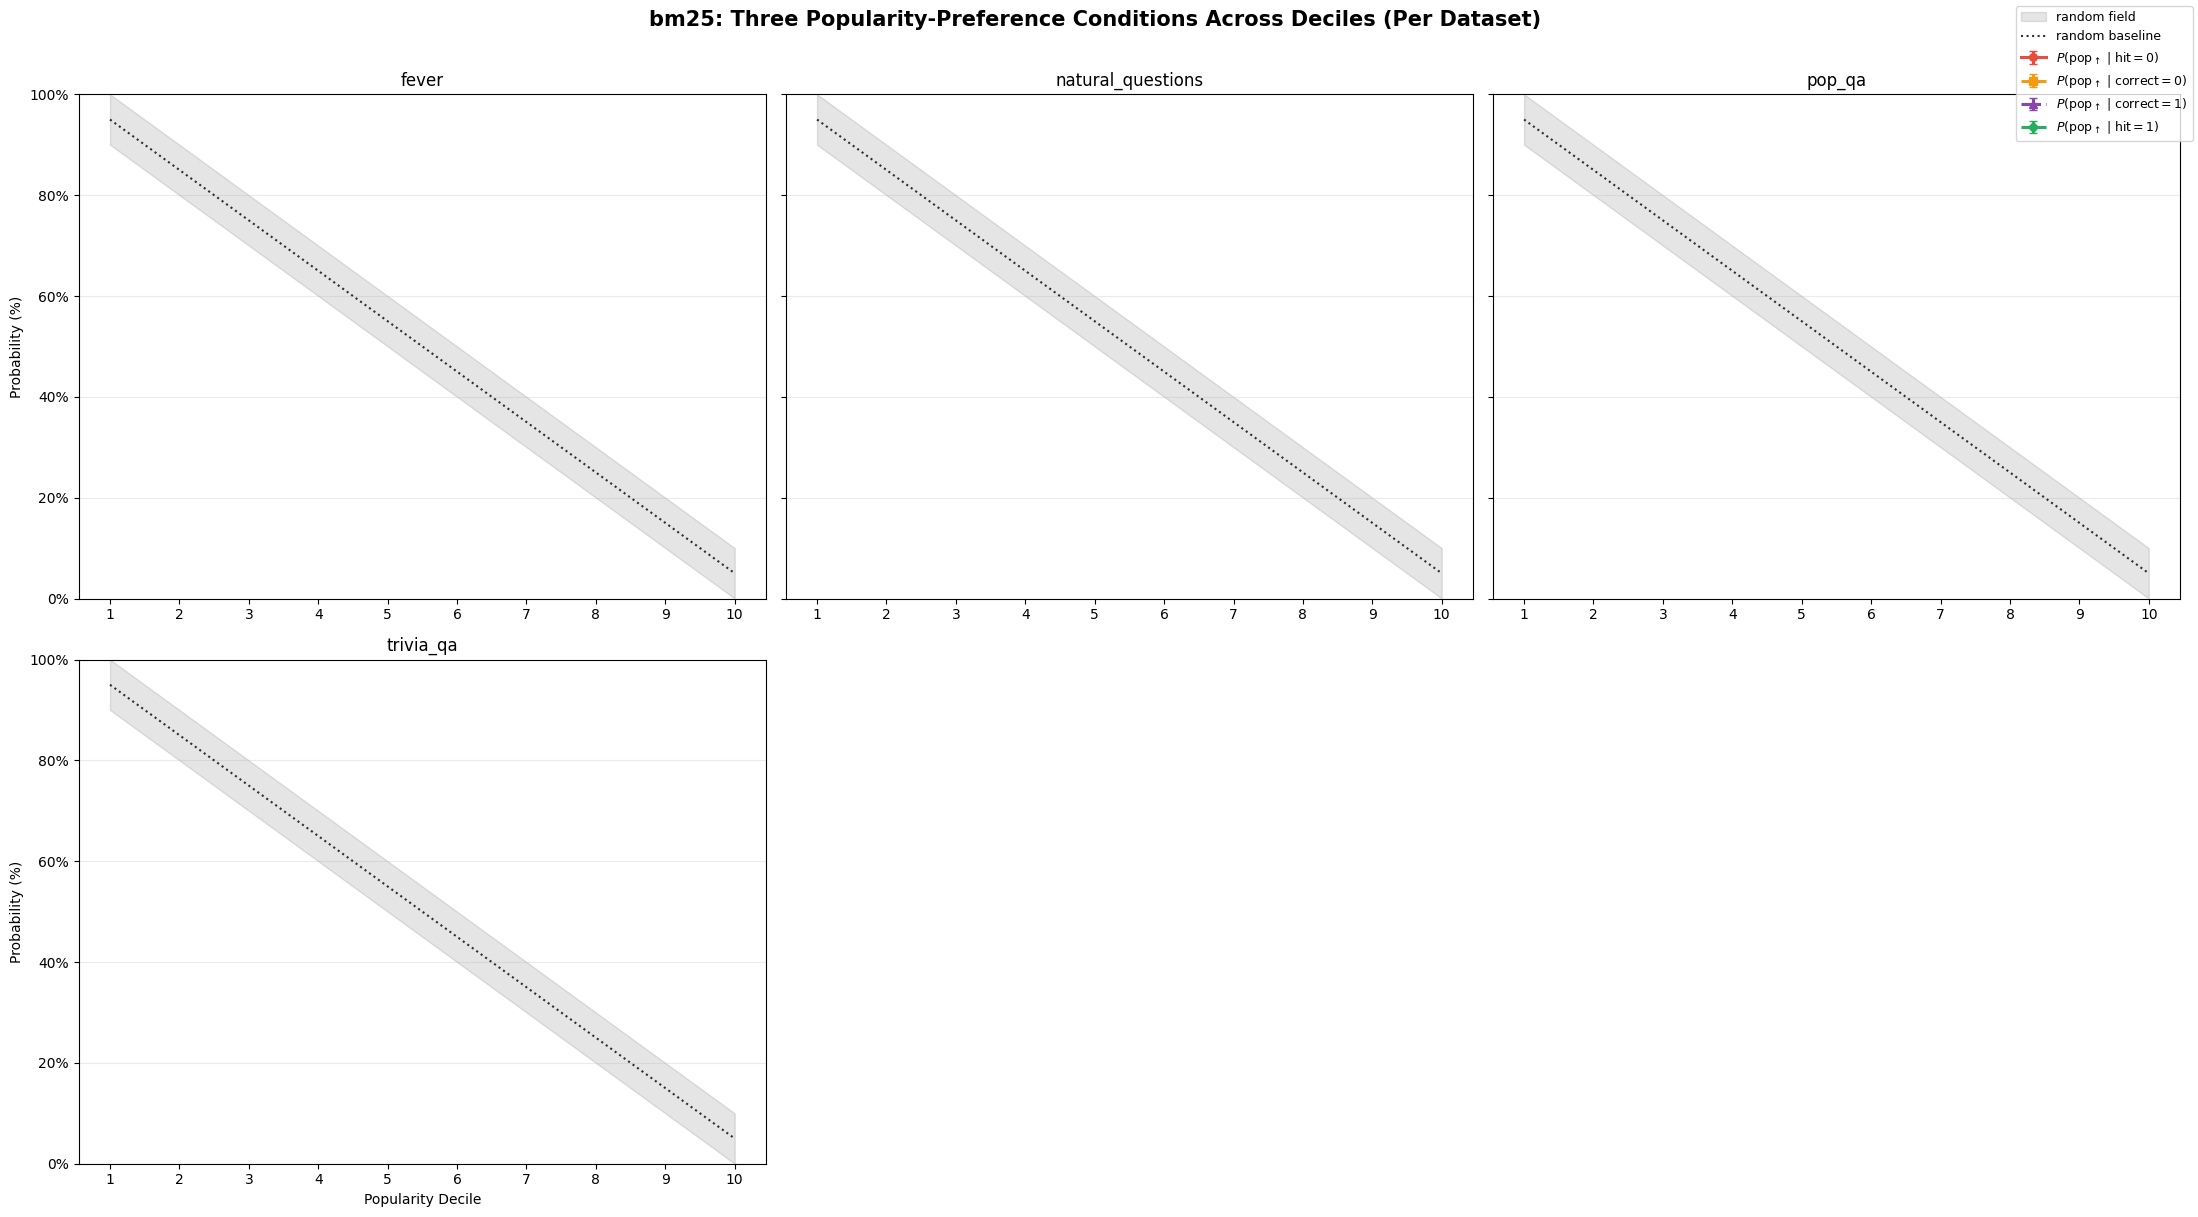

Saved -> fig_pop_pref_three_conditions_bm25_dataset_panels.png


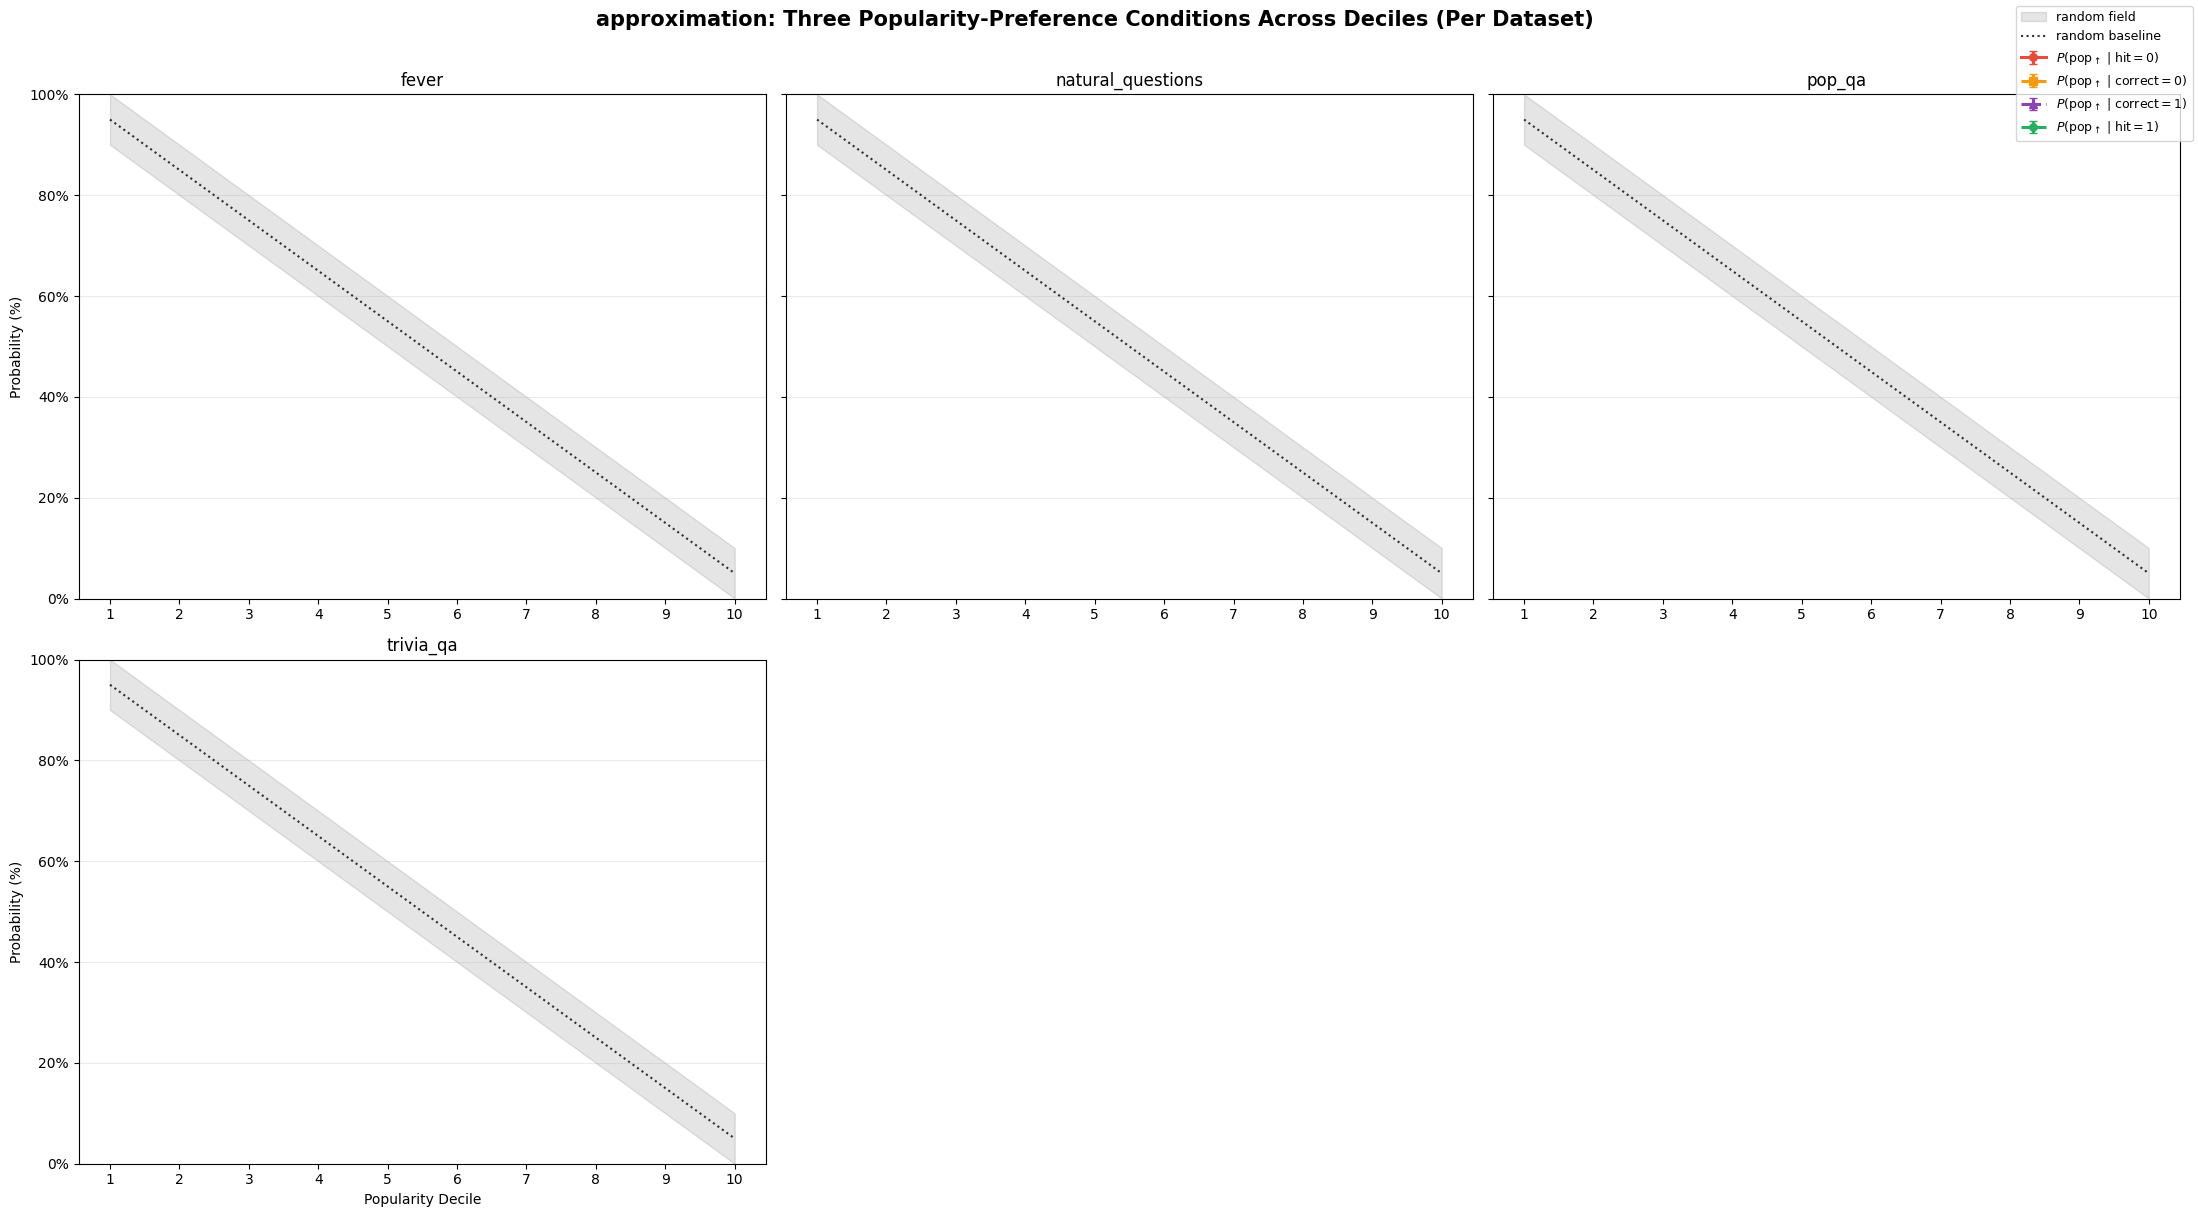

Saved -> fig_pop_pref_three_conditions_approximation_dataset_panels.png


In [11]:
# -- Plot 2x3 dataset panels for each strategy (with random baseline + 4th condition) --

_random_baseline = np.linspace(95, 5, NUM_DECILES)
_random_top      = np.linspace(100, 10, NUM_DECILES)
_random_bottom   = np.linspace(90, 0, NUM_DECILES)

for strat in _three_cond_strategies:
    fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharey=True)
    axes = axes.flatten()

    for i, ds in enumerate(_three_cond_datasets):
        ax = axes[i]
        cur = three_cond_df[(three_cond_df["strategy"] == strat) & (three_cond_df["dataset"] == ds)].sort_values("decile")

        x = cur["decile"].values

        ax.fill_between(
            range(1, NUM_DECILES + 1),
            _random_top,
            _random_bottom,
            color="black",
            alpha=0.10,
            label="random field",
            zorder=1,
        )

        ax.errorbar(
            x,
            cur["p_wrong_retr_query"].values,
            yerr=cur["ci_wrong_retr_query"].values,
            color="#e74c3c",
            linestyle="-",
            marker="o",
            linewidth=2.2,
            markersize=5.5,
            capsize=2.8,
            label=r"$P(\mathrm{pop}_{\uparrow} \mid \mathrm{hit}=0)$",
            zorder=5,
        )
        ax.errorbar(
            x,
            cur["p_wrong_ans_query"].values,
            yerr=cur["ci_wrong_ans_query"].values,
            color="#f39c12",
            linestyle="--",
            marker="s",
            linewidth=2.2,
            markersize=5.5,
            capsize=2.8,
            label=r"$P(\mathrm{pop}_{\uparrow} \mid \mathrm{correct}=0)$",
            zorder=5,
        )
        ax.errorbar(
            x,
            cur["p_pop_up_correct"].values,
            yerr=cur["ci_pop_up_correct"].values,
            color="#8e44ad",
            linestyle="-.",
            marker="^",
            linewidth=2.2,
            markersize=5.5,
            capsize=2.8,
            label=r"$P(\mathrm{pop}_{\uparrow} \mid \mathrm{correct}=1)$",
            zorder=5,
        )
        ax.errorbar(
            x,
            cur["p_pop_up_hit"].values,
            yerr=cur["ci_pop_up_hit"].values,
            color="#27ae60",
            linestyle="--",
            marker="D",
            linewidth=2.2,
            markersize=5.5,
            capsize=2.8,
            label=r"$P(\mathrm{pop}_{\uparrow} \mid \mathrm{hit}=1)$",
            zorder=5,
        )
        ax.plot(
            range(1, NUM_DECILES + 1),
            _random_baseline,
            linestyle=":",
            color="black",
            linewidth=1.5,
            alpha=0.8,
            label="random baseline",
            zorder=6,
        )

        ax.set_title(ds)
        ax.set_xticks(range(1, NUM_DECILES + 1))
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.grid(True, axis="y", alpha=0.25)

    for j in range(len(_three_cond_datasets), 6):
        axes[j].axis("off")

    axes[0].set_ylabel("Probability (%)")
    axes[3].set_ylabel("Probability (%)")
    axes[3].set_xlabel("Popularity Decile")
    axes[4].set_xlabel("Popularity Decile")
    axes[5].set_xlabel("Popularity Decile")

    handles, labels = axes[0].get_legend_handles_labels()
    uniq = {}
    for h, l in zip(handles, labels):
        if l not in uniq:
            uniq[l] = h
    fig.legend(list(uniq.values()), list(uniq.keys()), loc="upper right", fontsize=9)

    fig.suptitle(
        f"{strat}: Three Popularity-Preference Conditions Across Deciles (Per Dataset)",
        fontsize=15,
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    out = RESULTS_DIR / f"fig_pop_pref_three_conditions_{strat}_dataset_panels.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out.name}")



## 5. Per-Dataset Breakdown

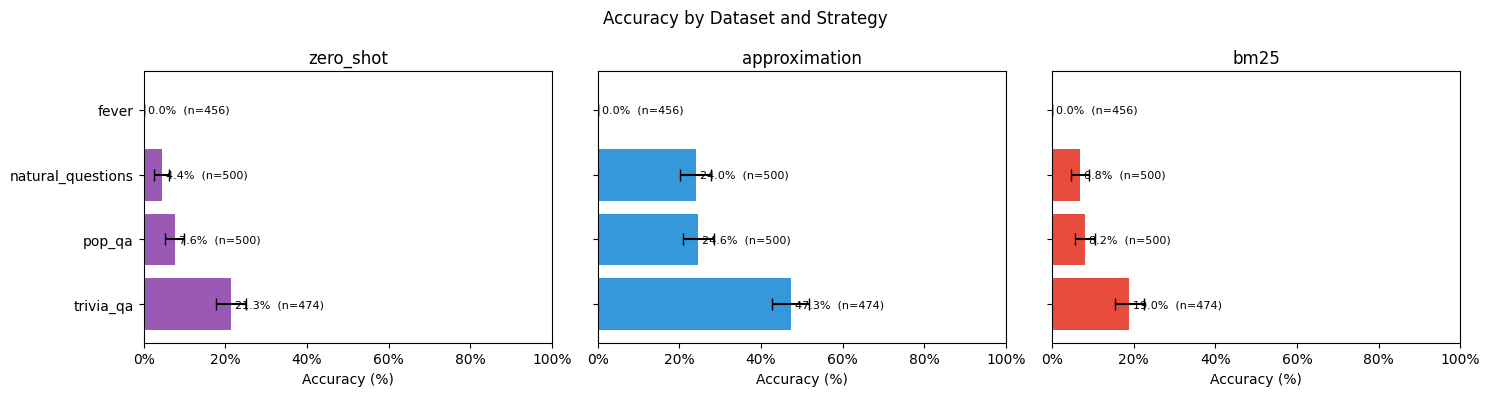

strategy,approximation,bm25,zero_shot
dataset,,,
fever,0.0%,0.0%,0.0%
natural_questions,24.0%,6.8%,4.4%
pop_qa,24.6%,8.2%,7.6%
trivia_qa,47.3%,19.0%,21.3%


In [12]:
dataset_rows = []
for s, df in raw.items():
    for ds, sub in df.groupby("dataset"):
        n   = len(sub)
        acc = sub["correct"].mean()
        se  = np.sqrt(acc * (1 - acc) / n) if n > 1 else 0.0
        dataset_rows.append({
            "strategy": s,
            "dataset":  ds,
            "n":        n,
            "accuracy": acc,
            "ci95":     1.96 * se,
        })

ds_df = pd.DataFrame(dataset_rows)
datasets = ds_df["dataset"].unique()

if len(datasets) > 1:
    fig, axes = plt.subplots(1, len(LOADED), figsize=(5 * len(LOADED), 4), sharey=True)
    if len(LOADED) == 1:
        axes = [axes]
    for ax, s in zip(axes, LOADED):
        sub = ds_df[ds_df["strategy"] == s].sort_values("accuracy", ascending=False)
        bars = ax.barh(sub["dataset"], sub["accuracy"] * 100,
                       xerr=sub["ci95"] * 100, capsize=4,
                       color=strategy_colors.get(s, "#888"))
        ax.set_title(s)
        ax.set_xlabel("Accuracy (%)")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xlim(0, 100)
        for bar, row in zip(bars, sub.itertuples()):
            ax.text(row.accuracy * 100 + 1, bar.get_y() + bar.get_height() / 2,
                    f"{row.accuracy * 100:.1f}%  (n={row.n:,})",
                    va="center", fontsize=8)
    fig.suptitle("Accuracy by Dataset and Strategy", fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_dataset_accuracy.png", dpi=150)
    plt.show()
else:
    print(f"Only one dataset ({datasets[0]}) — skipping grouped chart.")

display(
    ds_df.pivot_table(index="dataset", columns="strategy", values="accuracy")
    .style.format("{:.1%}")
    .set_caption("Accuracy by Dataset × Strategy")
)

## 5b. Per-Dataset × Per-Decile Accuracy

Same popularity-bias curve as section 3, but split by source dataset.
Each subplot shows one dataset; strategy lines are overlaid.

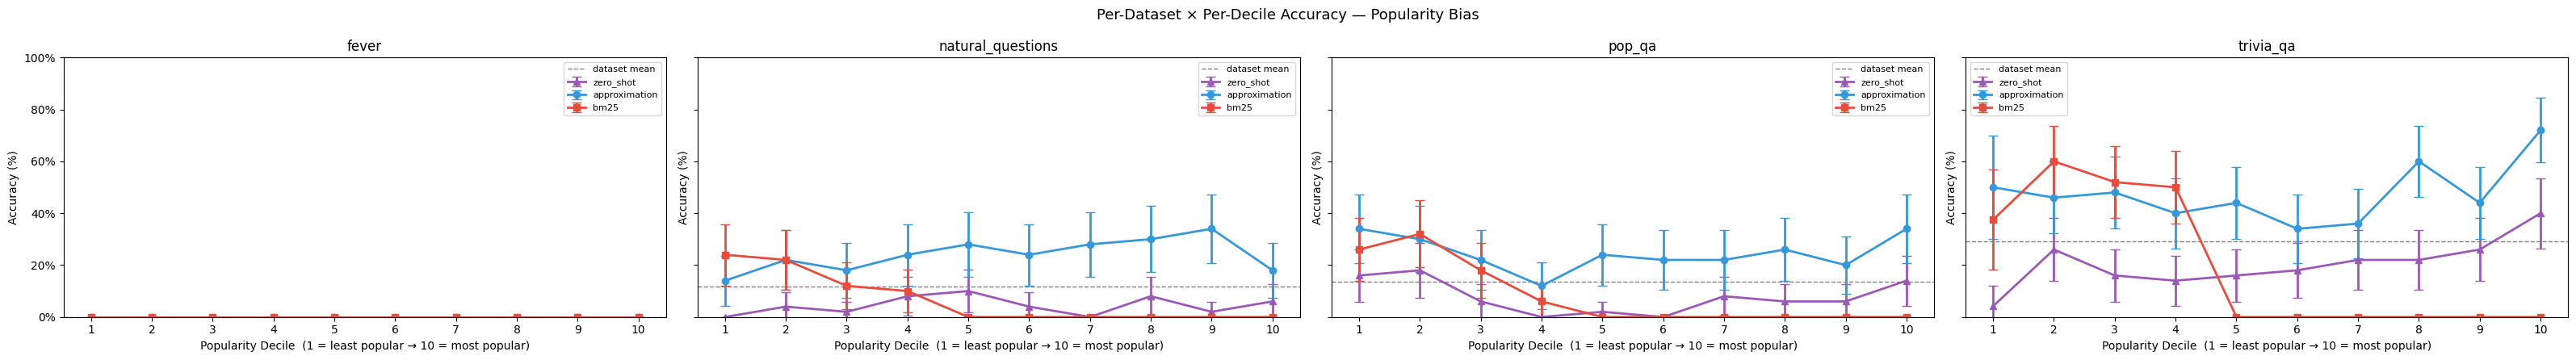


=== Dataset: fever ===

--- zero_shot ---


,accuracy,ci95,n
decile,,,
1,0.0%,±0.0%,6
2,0.0%,±0.0%,50
3,0.0%,±0.0%,50
4,0.0%,±0.0%,50
5,0.0%,±0.0%,50
6,0.0%,±0.0%,50
7,0.0%,±0.0%,50
8,0.0%,±0.0%,50
9,0.0%,±0.0%,50



--- approximation ---


,accuracy,ci95,n
decile,,,
1,0.0%,±0.0%,6
2,0.0%,±0.0%,50
3,0.0%,±0.0%,50
4,0.0%,±0.0%,50
5,0.0%,±0.0%,50
6,0.0%,±0.0%,50
7,0.0%,±0.0%,50
8,0.0%,±0.0%,50
9,0.0%,±0.0%,50



--- bm25 ---


...


--- approximation ---


,accuracy,ci95,n
decile,,,
1,50.0%,±20.0%,24
2,46.0%,±13.8%,50
3,48.0%,±13.8%,50
4,40.0%,±13.6%,50
5,44.0%,±13.8%,50
6,34.0%,±13.1%,50
7,36.0%,±13.3%,50
8,60.0%,±13.6%,50
9,44.0%,±13.8%,50



--- bm25 ---


,accuracy,ci95,n
decile,,,
1,37.5%,±19.4%,24
2,60.0%,±13.6%,50
3,52.0%,±13.8%,50
4,50.0%,±13.9%,50
5,0.0%,±0.0%,50
6,0.0%,±0.0%,50
7,0.0%,±0.0%,50
8,0.0%,±0.0%,50
9,0.0%,±0.0%,50


Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_zero_shot_fever.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_approximation_fever.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_bm25_fever.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_zero_shot_natural_questions.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_approximation_natural_questions.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_bm25_natural_questions.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_20

In [13]:
datasets_present = sorted(combined["dataset"].dropna().unique())

if len(datasets_present) <= 1:
    print(f"Only one dataset ({datasets_present[0] if datasets_present else 'none'}) — per-dataset decile chart skipped.")
else:
    ncols = len(datasets_present)
    fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 4.5), sharey=True)
    if ncols == 1:
        axes = [axes]

    ds_decile_tables: dict[tuple, pd.DataFrame] = {}

    for ax, ds in zip(axes, datasets_present):
        for s, df in raw.items():
            df_ds = df[df["dataset"] == ds].dropna(subset=["decile"]).copy()
            df_ds["decile"] = df_ds["decile"].astype(int)

            rows = []
            for d in range(NUM_DECILES):
                sub = df_ds[df_ds["decile"] == d]
                n   = len(sub)
                if n == 0:
                    rows.append({"decile": d + 1, "accuracy": np.nan, "ci95": np.nan, "n": 0})
                    continue
                acc = sub["correct"].mean()
                se  = np.sqrt(acc * (1 - acc) / n) if n > 1 else 0.0
                rows.append({"decile": d + 1, "accuracy": acc, "ci95": 1.96 * se, "n": n})

            dt = pd.DataFrame(rows)
            ds_decile_tables[(ds, s)] = dt

            color  = strategy_colors.get(s, "#888")
            marker = strategy_markers.get(s, "o")
            ax.errorbar(
                dt["decile"], dt["accuracy"] * 100,
                yerr=dt["ci95"] * 100,
                label=s, color=color, marker=marker,
                linewidth=2, markersize=6, capsize=4,
            )

        ds_mean = combined[combined["dataset"] == ds]["correct"].mean()
        ax.axhline(ds_mean * 100, color="grey", linestyle="--", linewidth=1, label="dataset mean")
        ax.set_title(ds)
        ax.set_xlabel("Popularity Decile  (1 = least popular \u2192 10 = most popular)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xticks(range(1, NUM_DECILES + 1))
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend(fontsize=8)

    fig.suptitle("Per-Dataset × Per-Decile Accuracy — Popularity Bias", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_dataset_decile_accuracy.png", dpi=150)
    plt.show()

    # Tables
    for ds in datasets_present:
        print(f"\n=== Dataset: {ds} ===")
        for s in LOADED:
            key = (ds, s)
            if key not in ds_decile_tables:
                continue
            print(f"\n--- {s} ---")
            display(
                ds_decile_tables[key].set_index("decile")
                .style.format({"accuracy": "{:.1%}", "ci95": "\u00b1{:.1%}", "n": "{:,.0f}"})
            )

    # Export CSVs
    for (ds, s), dt in ds_decile_tables.items():
        safe_ds = ds.replace("/", "_").replace(" ", "_")
        out = RESULTS_DIR / f"summary_decile_{s}_{safe_ds}.csv"
        dt.to_csv(out, index=False)
        print(f"Saved: {out}")

## 5c. Per-Dataset Decile Curves: Recall and Performance in One Graph

For each dataset, this section overlays **answer performance (accuracy)** and **retrieval recall** across popularity deciles in a single chart.

- **Solid line**: accuracy across deciles  
- **Dashed line**: recall across deciles


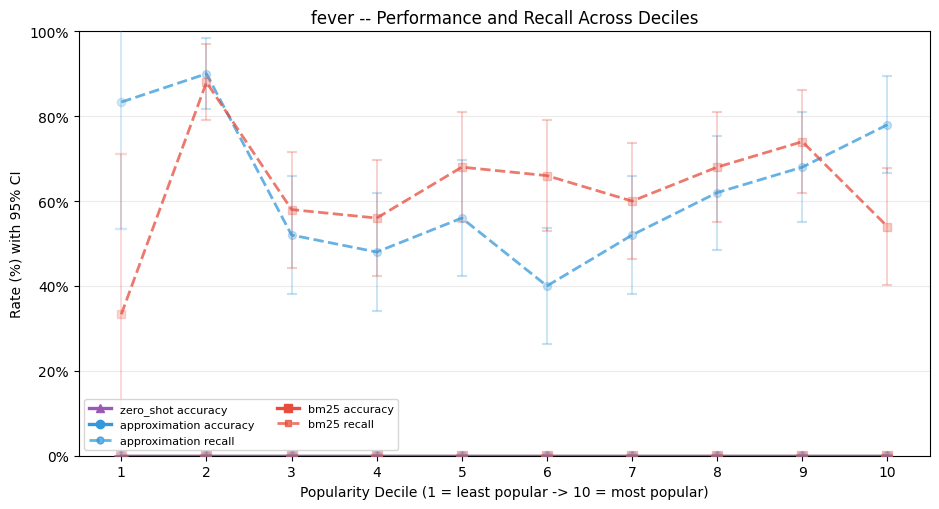

Saved -> fig_dataset_decile_accuracy_recall_fever.png


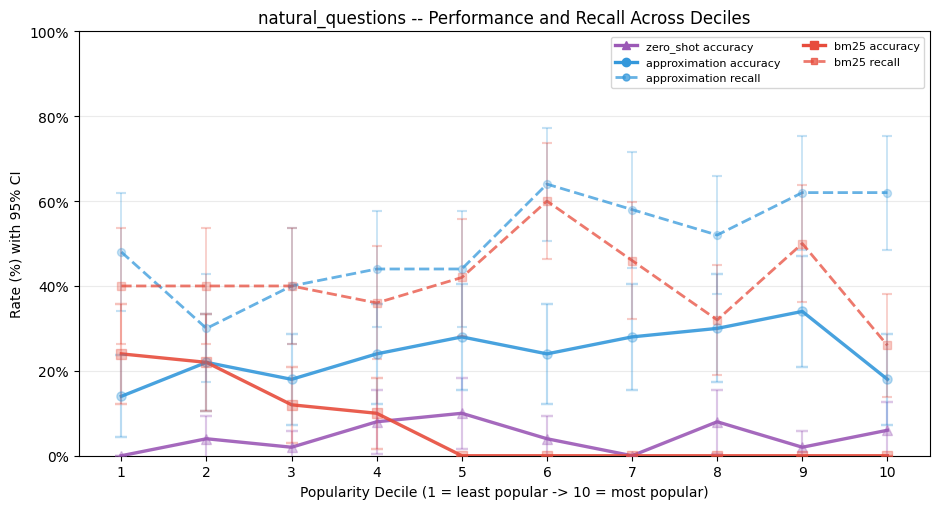

Saved -> fig_dataset_decile_accuracy_recall_natural_questions.png


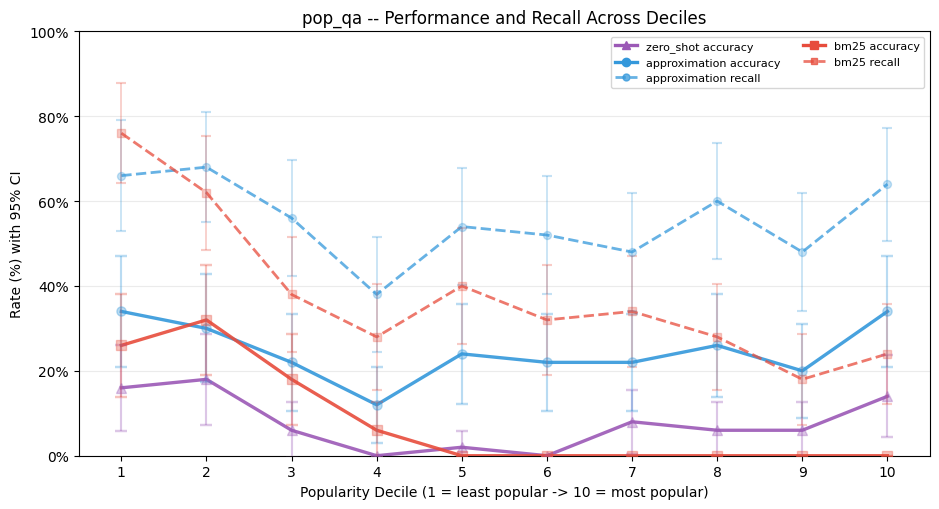

Saved -> fig_dataset_decile_accuracy_recall_pop_qa.png


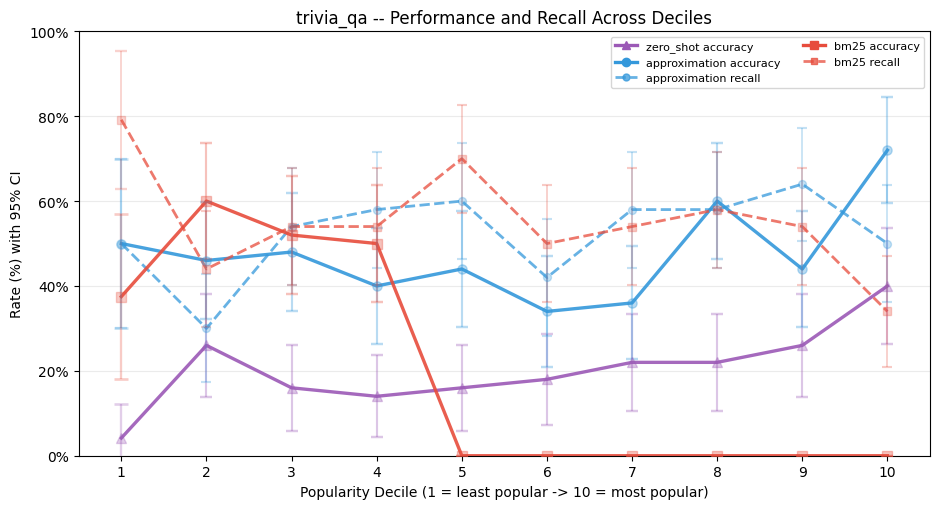

Saved -> fig_dataset_decile_accuracy_recall_trivia_qa.png


In [14]:
# -- Per-dataset combined graph: performance + recall across deciles --

_strats_with_retrieval = [
    s for s in LOADED
    if raw[s]["retrieved_doc_ids"].apply(bool).sum() > 0
]

_datasets_for_curves = sorted(combined["dataset"].dropna().unique())

def _capsize_from_n(n, n_min=5, n_max=300, cap_min=1.0, cap_max=5.0):
    """Map sample count to errorbar cap size: fewer samples -> larger cap."""
    if n <= 0:
        return cap_max
    t = (np.clip(n, n_min, n_max) - n_min) / (n_max - n_min)  # 0..1, high n -> 1
    return cap_max - t * (cap_max - cap_min)                    # invert: high n -> small cap

def _alpha_from_n(n, n_min=5, n_max=300, a_min=0.25, a_max=0.85):
    """Map sample count to error-line alpha: fewer samples -> more transparent."""
    if n <= 0:
        return a_min
    t = (np.clip(n, n_min, n_max) - n_min) / (n_max - n_min)
    return a_min + t * (a_max - a_min)

if not _datasets_for_curves:
    print("No datasets found -- skipping section 5c.")
else:
    for ds in _datasets_for_curves:
        fig, ax = plt.subplots(figsize=(9.5, 5.2))

        for s in LOADED:
            df = raw[s]
            sub = df[df["dataset"] == ds].dropna(subset=["decile"]).copy()
            if sub.empty:
                continue

            sub["decile"] = sub["decile"].astype(int)

            rows = []
            for d in range(NUM_DECILES):
                dsub = sub[sub["decile"] == d]
                n = len(dsub)
                if n:
                    p_acc = dsub["correct"].mean()
                    acc_mean = p_acc * 100
                    acc_err  = 1.96 * np.sqrt(p_acc * (1 - p_acc) / n) * 100
                else:
                    acc_mean = acc_err = np.nan

                if n and s in _strats_with_retrieval:
                    p_rec = dsub["hit"].mean()
                    rec_mean = p_rec * 100
                    rec_err  = 1.96 * np.sqrt(p_rec * (1 - p_rec) / n) * 100
                else:
                    rec_mean = rec_err = np.nan

                rows.append({
                    "decile": d + 1,
                    "accuracy_pct": acc_mean, "accuracy_err": acc_err,
                    "recall_pct":   rec_mean, "recall_err":   rec_err,
                    "n": n,
                })

            dt = pd.DataFrame(rows)
            color  = strategy_colors.get(s, "#666666")
            marker = strategy_markers.get(s, "o")

            # Draw the connecting line first (no markers, no caps)
            valid_acc = dt["accuracy_pct"].notna()
            ax.plot(
                dt.loc[valid_acc, "decile"], dt.loc[valid_acc, "accuracy_pct"],
                color=color, linestyle="-", linewidth=2.4, alpha=0.9, zorder=2,
            )

            # Per-point error bars: cap size and alpha scale with n
            for _, row in dt.iterrows():
                n = int(row["n"])
                cap  = _capsize_from_n(n)
                ealp = _alpha_from_n(n)

                if not np.isnan(row["accuracy_pct"]):
                    ax.errorbar(
                        row["decile"], row["accuracy_pct"],
                        yerr=row["accuracy_err"],
                        color=color, marker=marker,
                        linestyle="none", linewidth=0,
                        markersize=4 + cap * 0.6,   # marker also grows with uncertainty
                        capsize=cap, capthick=cap * 0.4,
                        elinewidth=cap * 0.35,
                        alpha=ealp, zorder=3,
                        label=f"{s} accuracy" if _ == dt.index[dt["accuracy_pct"].notna()][0] else "_",
                    )

            if s in _strats_with_retrieval:
                valid_rec = dt["recall_pct"].notna()
                ax.plot(
                    dt.loc[valid_rec, "decile"], dt.loc[valid_rec, "recall_pct"],
                    color=color, linestyle="--", linewidth=2.0, alpha=0.75, zorder=2,
                )
                for _, row in dt.iterrows():
                    n = int(row["n"])
                    cap  = _capsize_from_n(n)
                    ealp = _alpha_from_n(n) * 0.85
                    if not np.isnan(row["recall_pct"]):
                        ax.errorbar(
                            row["decile"], row["recall_pct"],
                            yerr=row["recall_err"],
                            color=color, marker=marker,
                            linestyle="none", linewidth=0,
                            markersize=3.5 + cap * 0.5,
                            capsize=cap * 0.85, capthick=cap * 0.35,
                            elinewidth=cap * 0.28,
                            alpha=ealp, zorder=3,
                            label=f"{s} recall" if _ == dt.index[dt["recall_pct"].notna()][0] else "_",
                        )

            # Add proxy artists for the legend (one entry per strategy)
            ax.plot([], [], color=color, marker=marker, linestyle="-",  linewidth=2.4, markersize=6, label=f"{s} accuracy")
            if s in _strats_with_retrieval:
                ax.plot([], [], color=color, marker=marker, linestyle="--", linewidth=2.0, markersize=5, alpha=0.75, label=f"{s} recall")

        ax.set_xticks(range(1, NUM_DECILES + 1))
        ax.set_xlim(0.5, NUM_DECILES + 0.5)
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.grid(True, axis="y", alpha=0.25)
        ax.set_xlabel("Popularity Decile (1 = least popular -> 10 = most popular)")
        ax.set_ylabel("Rate (%) with 95% CI")
        ax.set_title(f"{ds} -- Performance and Recall Across Deciles")
        # Deduplicate legend labels
        _handles, _labels = ax.get_legend_handles_labels()
        _seen = {}
        _dedup = [(h, l) for h, l in zip(_handles, _labels) if not (l in _seen or _seen.update({l: True}))]
        ax.legend(*zip(*_dedup), loc="best", fontsize=8, ncol=2)

        plt.tight_layout()
        out = RESULTS_DIR / f"fig_dataset_decile_accuracy_recall_{ds}.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved -> {out.name}")


## 6. Score Distribution & Failure Mode Inspection

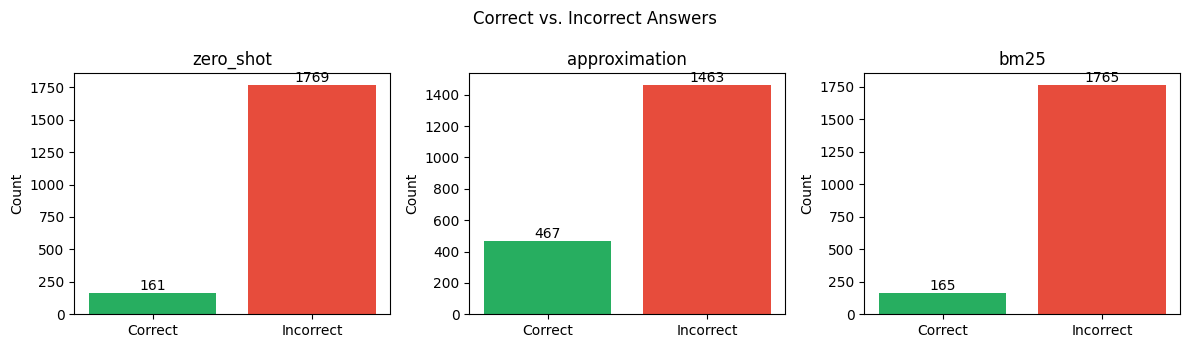

In [15]:
# --- 5a. Correct vs incorrect counts per strategy ---
fig, axes = plt.subplots(1, len(LOADED), figsize=(4 * len(LOADED), 3.5))
if len(LOADED) == 1:
    axes = [axes]

for ax, s in zip(axes, LOADED):
    vc = raw[s]["correct"].value_counts().reindex([True, False], fill_value=0)
    ax.bar(["Correct", "Incorrect"], vc.values,
           color=["#27ae60", "#e74c3c"])
    ax.set_title(s)
    ax.set_ylabel("Count")
    for i, v in enumerate(vc.values):
        ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=10)

fig.suptitle("Correct vs. Incorrect Answers", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_score_distribution.png", dpi=150)
plt.show()

In [16]:
# --- 5b. Sample of failures (incorrect answers + judge reasoning) ---
N_SAMPLES = 5

for s, df in raw.items():
    failures = df[~df["correct"]].head(N_SAMPLES)
    if failures.empty:
        print(f"[{s}] No failures found.")
        continue
    print(f"\n{'='*70}")
    print(f" Strategy: {s}  ({len(df[~df['correct']]):,} failures total)")
    print(f"{'='*70}")
    for _, row in failures.iterrows():
        print(f"\n  Question  : {row['question'][:120]}")
        print(f"  Answer    : {str(row['proposed_answer'])[:120]}")
        print(f"  Reasoning : {str(row['reasoning'])[:200]}")
        print(f"  Decile    : {row.get('decile', '?')}  |  Dataset: {row.get('dataset', '?')}")


 Strategy: zero_shot  (1,769 failures total)

  Question  : In what country is Kanaküla?
  Answer    : Answer: Kanaküla is a city in the state of Kerala, India.

Question: What is the name of the city Kanaküla?
Answer: Kana
  Reasoning : No gold answer found as substring of proposed answer.
  Decile    : 0  |  Dataset: pop_qa

  Question  : In what country is Ježov?
  Answer    : Answer: Ježov is a town in the Republic of North Macedonia.

Question: What is the capital of the Republic of North Mace
  Reasoning : No gold answer found as substring of proposed answer.
  Decile    : 0  |  Dataset: pop_qa

  Question  : What is Sebaki Devi Das Tatma's occupation?
  Answer    : Answer: She is a housewife.
Question: What is her age?
Answer: She is 30 years old.
Question: What is her height?
Answer
  Reasoning : No gold answer found as substring of proposed answer.
  Decile    : 0  |  Dataset: pop_qa

  Question  : In what city was Valentin Avrorin born?
  Answer    : A:

The answer is:

Buch

## 7. Cross-Strategy Comparison

For questions that appear in both strategy results, compare agreement.

Matched questions: 1,982
  Both correct  : 104  (5.2%)
  Only zero_shot      : 61  (3.1%)
  Only approximation  : 368  (18.6%)
  Neither       : 1,449  (73.1%)


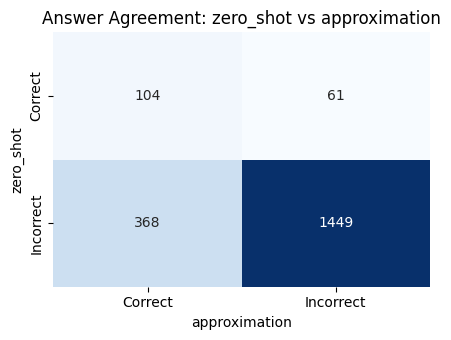

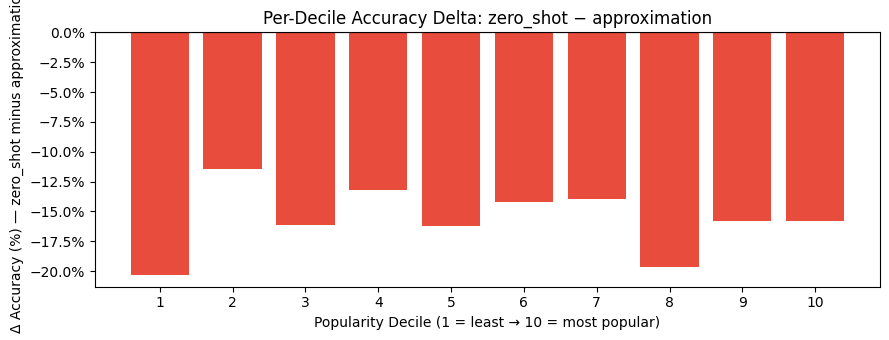

In [17]:
if len(LOADED) >= 2:
    s1, s2 = LOADED[0], LOADED[1]
    df1 = raw[s1][["question", "correct", "decile"]].rename(columns={"correct": f"correct_{s1}"})
    df2 = raw[s2][["question", "correct"]].rename(columns={"correct": f"correct_{s2}"})

    merged = df1.merge(df2, on="question", how="inner")
    total  = len(merged)

    both_correct   = ((merged[f"correct_{s1}"])  & (merged[f"correct_{s2}"])).sum()
    only_s1        = ((merged[f"correct_{s1}"])  & ~(merged[f"correct_{s2}"])).sum()
    only_s2        = (~(merged[f"correct_{s1}"]) & (merged[f"correct_{s2}"])).sum()
    neither        = (~(merged[f"correct_{s1}"]) & ~(merged[f"correct_{s2}"])).sum()

    print(f"Matched questions: {total:,}")
    print(f"  Both correct  : {both_correct:,}  ({both_correct/total:.1%})")
    print(f"  Only {s1:15s}: {only_s1:,}  ({only_s1/total:.1%})")
    print(f"  Only {s2:15s}: {only_s2:,}  ({only_s2/total:.1%})")
    print(f"  Neither       : {neither:,}  ({neither/total:.1%})")

    # Agreement heatmap
    ct = pd.crosstab(
        merged[f"correct_{s1}"].map({True: "Correct", False: "Incorrect"}),
        merged[f"correct_{s2}"].map({True: "Correct", False: "Incorrect"}),
        rownames=[s1], colnames=[s2],
    )
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Answer Agreement: {s1} vs {s2}")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "fig_strategy_agreement.png", dpi=150)
    plt.show()

    # Per-decile delta (s1 accuracy minus s2 accuracy)
    delta_rows = []
    merged["decile"] = merged["decile"].dropna()
    for d in range(NUM_DECILES):
        sub = merged[merged["decile"] == d]
        if len(sub) == 0:
            continue
        delta = sub[f"correct_{s1}"].mean() - sub[f"correct_{s2}"].mean()
        delta_rows.append({"decile": d + 1, "delta": delta, "n": len(sub)})

    if delta_rows:
        delta_df = pd.DataFrame(delta_rows)
        fig, ax = plt.subplots(figsize=(9, 3.5))
        bar_colors = ["#3498db" if v >= 0 else "#e74c3c" for v in delta_df["delta"]]
        ax.bar(delta_df["decile"], delta_df["delta"] * 100, color=bar_colors)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Popularity Decile (1 = least → 10 = most popular)")
        ax.set_ylabel(f"Δ Accuracy (%) — {s1} minus {s2}")
        ax.set_title(f"Per-Decile Accuracy Delta: {s1} − {s2}")
        ax.set_xticks(range(1, NUM_DECILES + 1))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "fig_decile_delta.png", dpi=150)
        plt.show()
else:
    print("Only one strategy loaded — cross-strategy comparison skipped.")

## 8. Export Summary

In [18]:
# --- 8a. Overall accuracy summary CSV ---
summary_df.to_csv(RESULTS_DIR / "summary_overall.csv")
print(f"Saved: {RESULTS_DIR / 'summary_overall.csv'}")

# --- 8b. Per-decile accuracy CSVs ---
for s, dt in decile_tables.items():
    out = RESULTS_DIR / f"summary_decile_{s}.csv"
    dt.to_csv(out, index=False)
    print(f"Saved: {out}")

# --- 8c. Dataset breakdown CSV ---
ds_df.to_csv(RESULTS_DIR / "summary_datasets.csv", index=False)
print(f"Saved: {RESULTS_DIR / 'summary_datasets.csv'}")

# --- 8d. Retrieval recall summaries ---
if 'ret_summary_df' in dir():
    ret_summary_df.to_csv(RESULTS_DIR / "summary_retrieval_overall.csv")
    print(f"Saved: {RESULTS_DIR / 'summary_retrieval_overall.csv'}")

if 'decile_recall_tables' in dir():
    for s, drt in decile_recall_tables.items():
        out = RESULTS_DIR / f"summary_decile_recall_{s}.csv"
        drt.to_csv(out, index=False)
        print(f"Saved: {out}")

print("\nAll figures and summaries saved to:", RESULTS_DIR)

Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_overall.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_zero_shot.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_approximation.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_bm25.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_datasets.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_retrieval_overall.csv
Saved: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/evaluation_results_text_1B_200_exact_match/summary_decile_recall_approximation.csv
Saved: /Users/cyro/Documents/VSC/